In [1]:
import sys
import colorsys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
from matplotlib import cm 
from epiweeks import Week
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 14 # Axis labels
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick labels
plt.rcParams['font.size'] = 14  # General font size
FONT = 12

In [2]:
dict_models_name = {157: 'UERJ-SARIMAX-2', 156: 'Dengue oracle M2', 155: 'Dengue Oracle M1', 135:'GHR Model', 
                    133:'Chronos-Bolt', 158: 'Cornell PEH', 143: 'Model fourier-\ngravidade', 144:'Beat it', 
                    150: 'LNCC-AR_p-1', 
        145: 'CNNLSTM' , 141: 'Kaust Geohealth', 136: 'Imperial-TFT Model', 137: 'LSTM-RF model', 
                    138: 'TSMixer ZKI-PH4', 154: 'LNCC-SURGE-1', 152: 'LNCC-CLIDENGO-1', 134: 'ISI_Dengue_Model', 
                    108:'IMPA-TECH'} 

Define a color palette: 

In [3]:
keys = [157, 156, 155, 135, 133, 158, 143, 144, 150, 
        145, 141, 136, 137, 138, 154, 152, 134, 108]

n = len(keys)

# Gerar cores bem espaçadas no círculo HSV
def generate_vibrant_colors(n, s=0.8, v=0.9):
    hues = np.linspace(0, 1, n, endpoint=False)
    colors = [colorsys.hsv_to_rgb(h, s, v) for h in hues]
    return colors

colors = generate_vibrant_colors(n)

# Criar dict {key: color} garantindo que nenhuma cor é cinza/preto
color_palette = {k: colors[i] for i, k in enumerate(dict_models_name.values())}

Load data: 

In [4]:
dates_24 = pd.date_range(start= Week(2023, 41).startdate().strftime('%Y-%m-%d'),
              end= Week(2024, 40).startdate().strftime('%Y-%m-%d'),
              freq='W-SUN')

dates_25 = pd.date_range(start= Week(2024, 41).startdate().strftime('%Y-%m-%d'),
              end= Week(2025, 40).startdate().strftime('%Y-%m-%d'),
              freq='W-SUN')

In [5]:
data_agg = pd.read_csv('predictions/dengue_agg.csv.gz')
data_agg.date = pd.to_datetime(data_agg.date)

data_agg = data_agg.rename(columns = {'uf':'state'})
casos_2024 = data_agg.loc[data_agg.date.isin(dates_24)].rename(columns = {'casos':'casprov_2024'})
casos_2025 = data_agg.loc[data_agg.date.isin(dates_25)].rename(columns = {'casos':'casprov_2025'})


In [6]:
casos_2025

,date,casprov_2025,state
770,2024-10-06,137.0,AL
771,2024-10-13,120.0,AL
772,2024-10-20,101.0,AL
773,2024-10-27,106.0,AL
774,2024-11-03,90.0,AL
...,...,...,...
22189,2025-08-31,356.0,PR
22190,2025-09-07,503.0,PR
22191,2025-09-14,880.0,PR
22192,2025-09-21,1301.0,PR


load forecasts: 

In [7]:
df_for = pd.read_csv('predictions/forecasts_2nd_sprint_update.csv.gz')
df_for.date = pd.to_datetime(df_for.date)
df_for = df_for.sort_values(by ='date')
df_for.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,state
0,2025-10-05,0.000,0.0,0.0,101.922668,356.781097,790.528656,1992.101929,2496.932953,2749.348465,133,DF
7446,2025-10-05,31.000,42.0,66.0,123.000000,265.500000,595.000000,1346.300000,2272.350000,3548.200000,144,PR
7499,2025-10-05,4.000,5.0,7.0,12.000000,20.000000,35.000000,56.000000,77.000000,101.000000,144,PI
7552,2025-10-05,54.000,67.0,91.0,149.750000,279.500000,507.000000,858.100000,1215.050000,1692.075000,144,PE
7605,2025-10-05,26.975,35.0,46.0,73.000000,121.000000,195.000000,313.100000,408.050000,564.100000,144,PB


Load population:

In [8]:
df_pop = pd.read_csv('predictions/pop_states_2024.csv.gz')

df_pop.head()

,state,population
0,AC,880631
1,AL,3220104
2,AM,4281209
3,AP,802837
4,BA,14850513


Load best models by state:

In [9]:
df_bm = pd.read_csv('results/best_model_by_state_norm.csv', index_col = 'Unnamed: 0')

df_bm.head()

,best_model_norm,state
158,144,AC
80,135,AL
160,144,AM
377,158,AP
109,136,BA


Compute the ensemble

In [10]:
df_median_ens = pd.read_csv('predictions/ensemble_median_2026.csv.gz')
df_median_ens.date = pd.to_datetime(df_median_ens.date)
df_median_ens.head()

,date,state,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,mu,sigma
0,2025-10-05,DF,1.0,2.0,4.0,9.0,36.316665,86.010745,157.0,257.874179,398.000000,E_median_top,3.108446,1.468397
1,2025-10-12,DF,2.0,2.0,4.0,10.0,34.649051,94.248957,196.0,292.000000,405.445650,E_median_top,3.349067,1.355086
2,2025-10-19,DF,2.0,3.0,5.0,12.0,35.146760,90.000000,180.0,283.101775,421.337491,E_median_top,3.368291,1.364894
3,2025-10-26,DF,2.0,3.0,6.0,14.0,40.399247,104.193800,205.0,286.000000,435.649320,E_median_top,3.384992,1.373416
4,2025-11-02,DF,3.0,4.0,7.0,16.0,63.000000,129.745682,270.0,358.107097,500.000000,E_median_top,3.656610,1.305125


Plot the ensemble versus the individual models: 

In [11]:
def make_comp_plot(ax, state, best_model, df_median_ens, df_for, cumulative = False,language = 'en'):

    if language == 'en':
        lb_casos = 'Inc. 2025'
        lb_models = 'Other models'
        lb_best_model = 'Best model'
        ylabel = 'Incidence of probable cases'
        lb_thr = 'Threshold'
    elif language == 'pt':
        lb_casos = 'Inc. 2025'
        lb_models = 'Outros modelos'
        lb_best_model = 'Melhor modelo'
        ylabel = 'Incidência de casos prováveis'
        lb_thr = 'Limiar'

    casos = casos_2025.loc[casos_2025.state == state]

    pop = df_pop.loc[df_pop.state == state]['population'].values[0]
    df_ens_ = df_median_ens.loc[(df_median_ens.state == state)]


    if cumulative:
        ax.plot(df_ens_.date[:casos.shape[0]], np.cumsum(100000*casos.casprov_2025/pop), color = 'black', linewidth = 2, linestyle = 'dotted', zorder = 20, label = lb_casos )

        ax.plot(df_ens_.date, np.cumsum(100000*df_ens_.pred/pop), color = 'blue', linewidth = 2, linestyle = '--', zorder = 20, label = 'Ensemble' )
        
    else: 

        ax.plot(df_ens_.date[:casos.shape[0]], 100000*casos.casprov_2025/pop, color = 'black', linewidth = 2, linestyle = 'dotted', zorder = 20, label = lb_casos )

        ax.plot(df_ens_.date, 100000*df_ens_.pred/pop, color = 'blue', linewidth = 2, linestyle = '--', zorder = 20, label = 'Ensemble' )

        ax.fill_between(df_ens_.date, 100000*df_ens_.lower_90/pop,
                        100000*df_ens_.upper_90/pop,
                        color = 'blue', alpha = 0.2)


    for m in df_for.model_id.unique():

        df_m = df_for.loc[(df_for.state == state) & (df_for.model_id == m)]

        if cumulative:
            ax.plot(df_m.date, np.cumsum(100000*df_m.pred/pop), alpha = 0.3,  color = 'tab:grey')

        else:
            ax.plot(df_m.date, 100000*df_m.pred/pop, alpha = 0.3,  color = 'tab:grey')

    ax.plot([], [], color = 'tab:grey', alpha = 0.3,  label = lb_models)

    m = best_model 

    df_m = df_for.loc[(df_for.state == state) & (df_for.model_id == m)]

    if cumulative: 
        ax.plot(df_m.date, np.cumsum(100000*df_m.pred/pop), color = 'tab:red', label =f'{lb_best_model} ID {m}')

    else: 
        ax.plot(df_m.date, 100000*df_m.pred/pop, color = 'tab:red', label =f'{lb_best_model} ID {m}')

    if cumulative: 
        ax.axhline(300, color = 'tab:orange', linestyle = 'dotted', label = lb_thr, linewidth = 2)

    ax.set_ylabel(ylabel)
    ax.set_title(f'{state} -  2026')
    ax.legend()
    ax.grid()


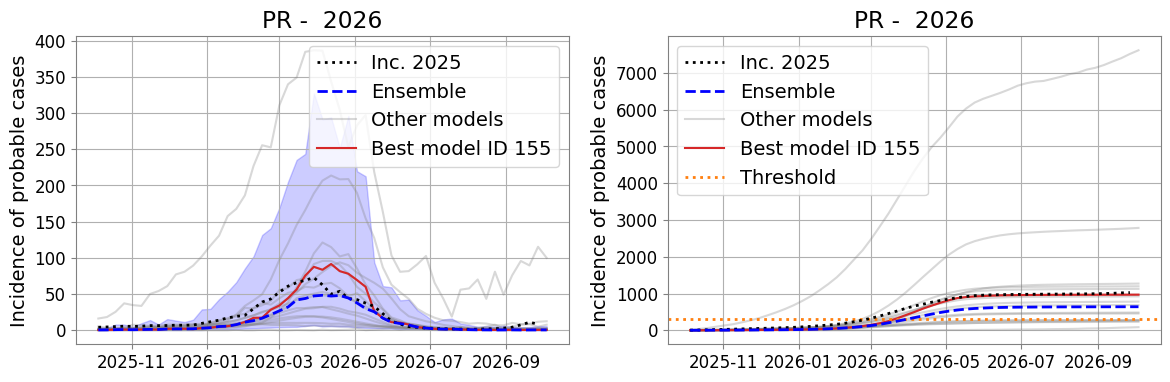

In [12]:
state = 'PR'
best_model = 155 

_, ax = plt.subplots(1,2, figsize = (14, 4))

make_comp_plot(ax[0], state, best_model, df_median_ens, df_for)
make_comp_plot(ax[1], state, best_model, df_median_ens, df_for, cumulative=True)


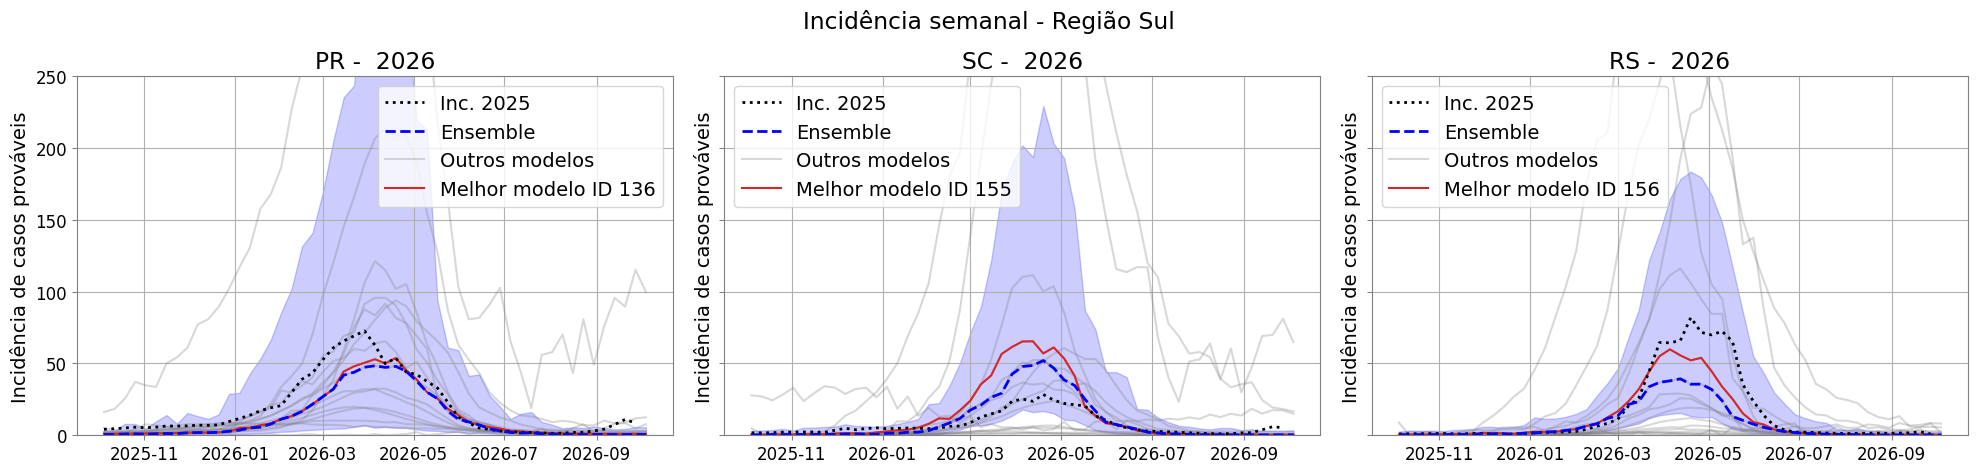

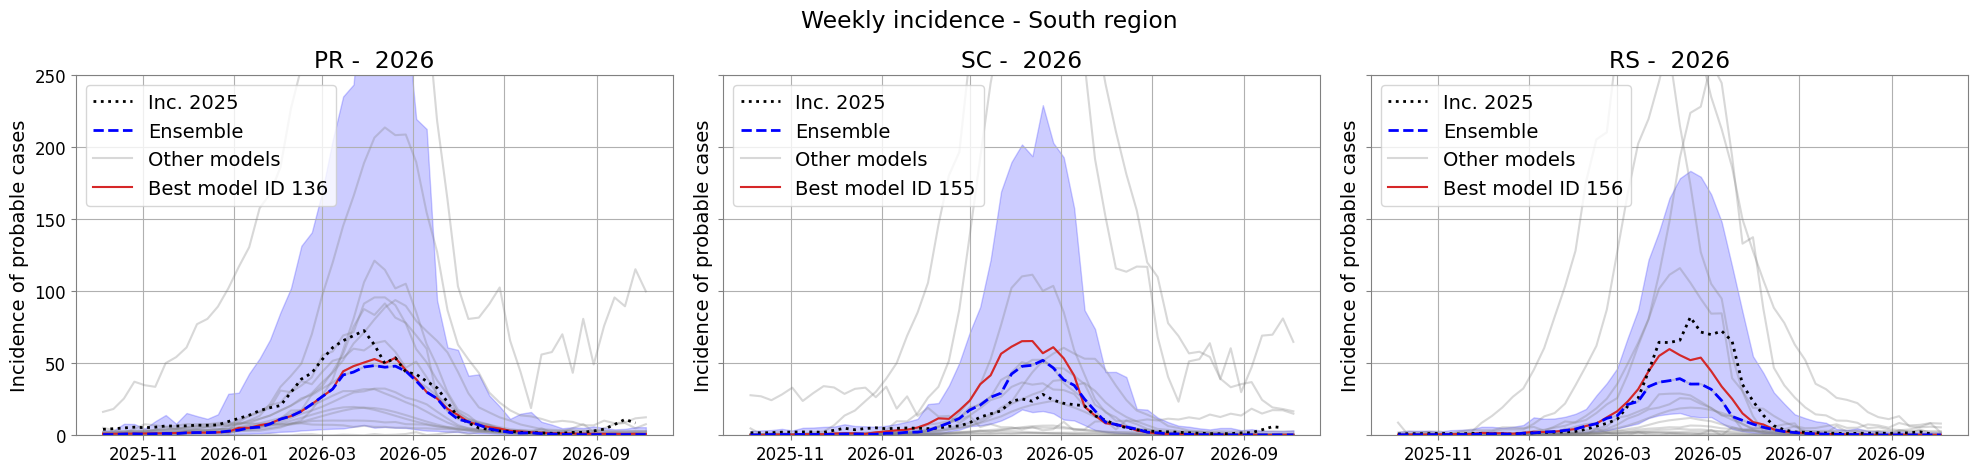

In [13]:
for language in ['pt', 'en']:
    _, ax = plt.subplots(1,3, figsize = (20, 5), sharey = True)

    for state, ax_ in zip(['PR', 'SC', 'RS'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        #best_model = 136
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0].set_ybound([0, 250])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Sul', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - South region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_sul_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

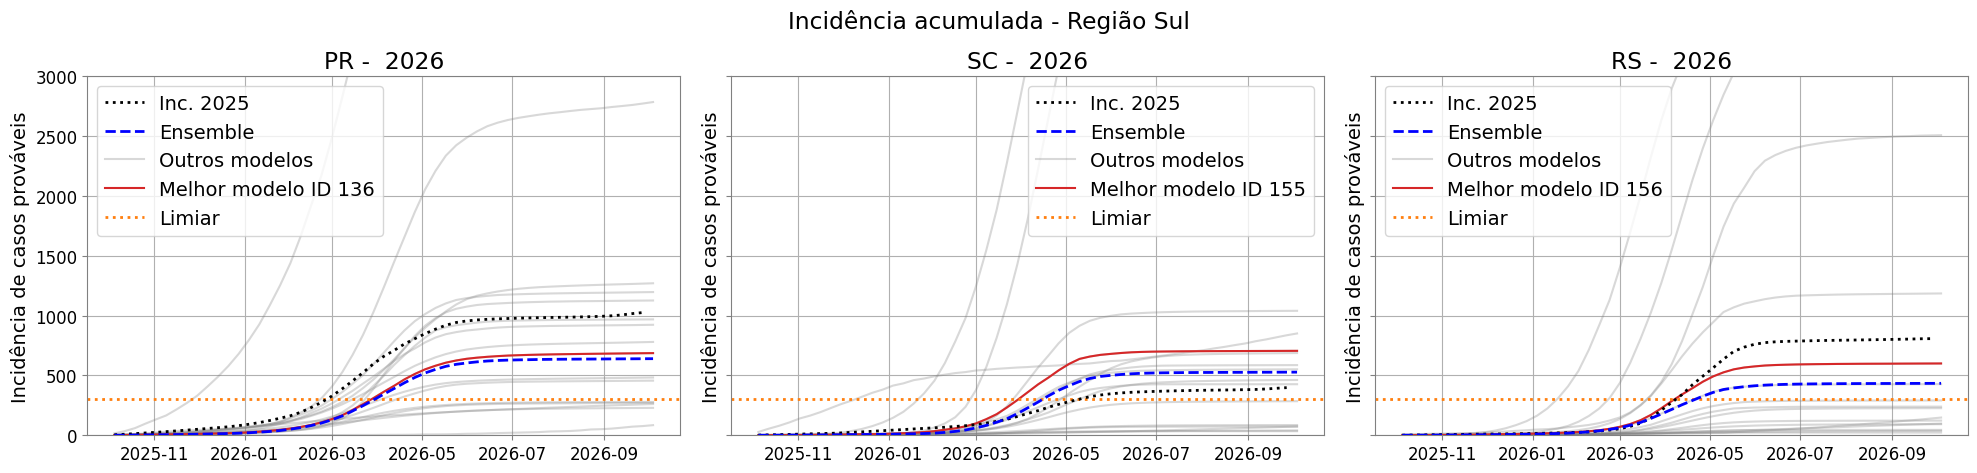

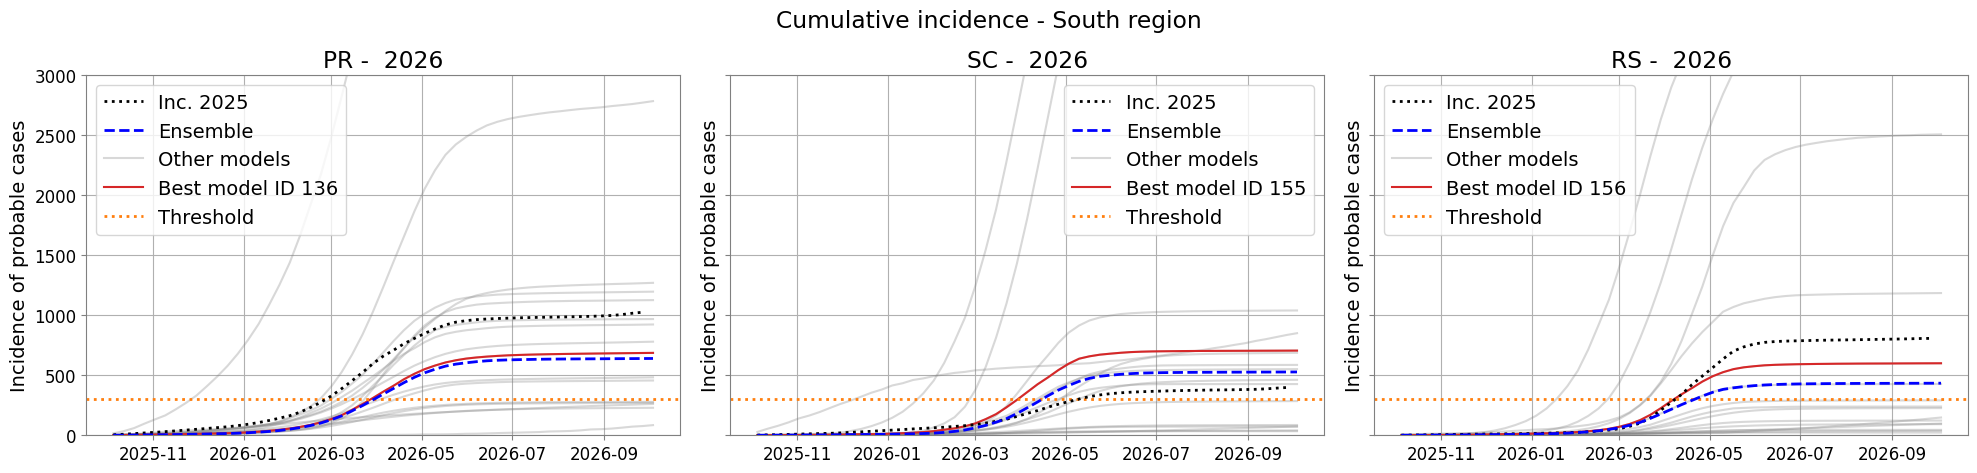

In [14]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(1,3, figsize = (20, 5), sharey = True)

    for state, ax_ in zip(['PR', 'SC', 'RS'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        #best_model = 133
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0].set_ybound([0, 3000])


    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Sul', y = 0.95)
    else: 
        plt.suptitle('Cumulative incidence - South region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_sul_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

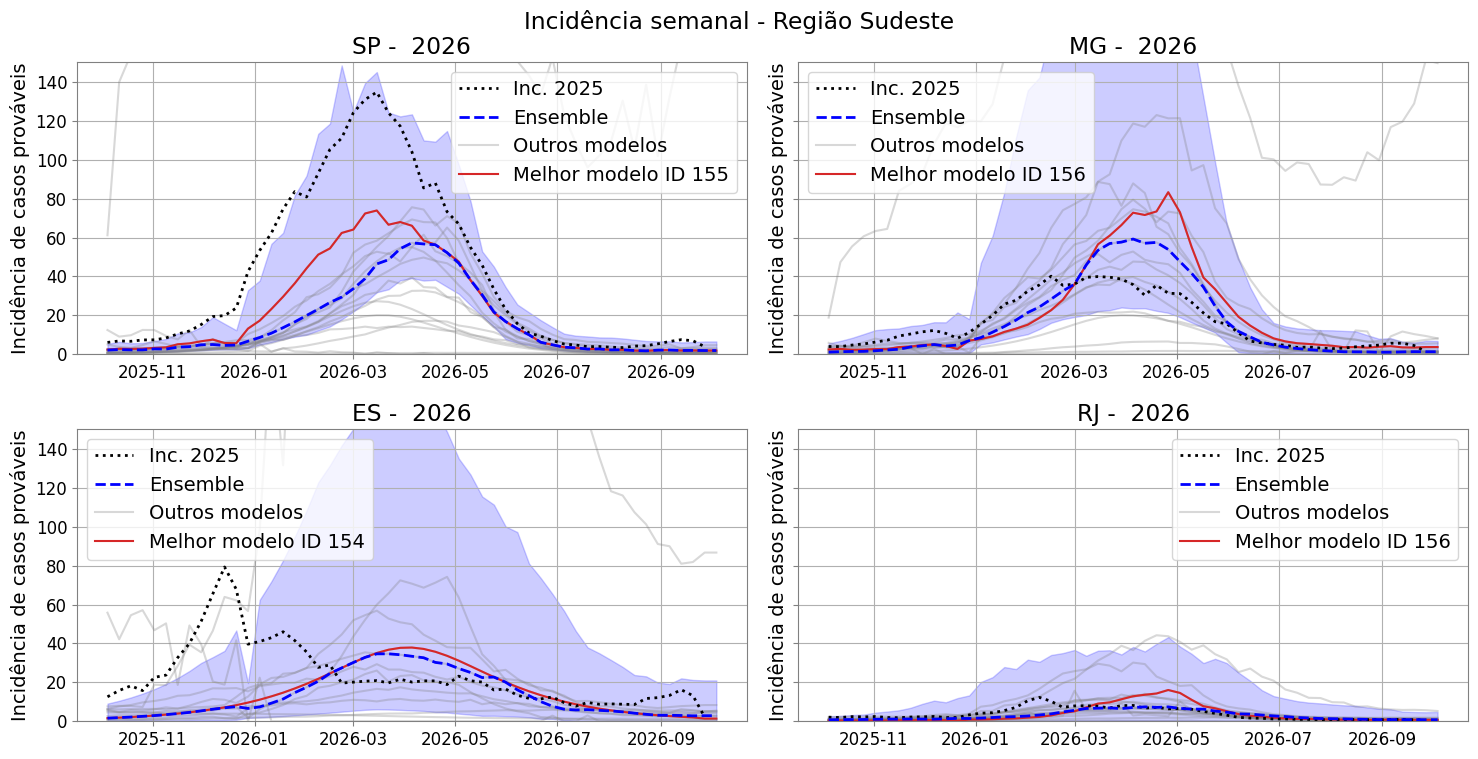

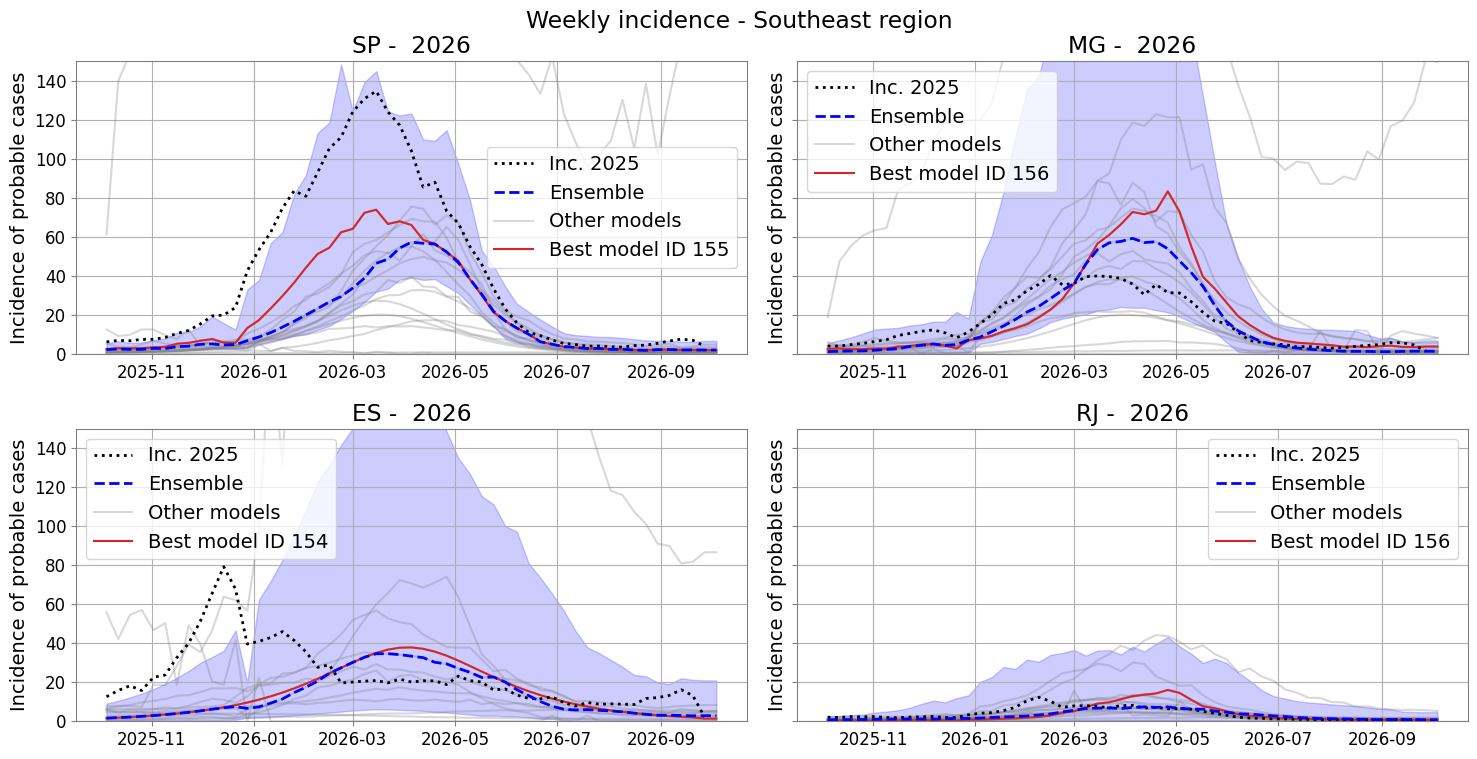

In [15]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['SP', 'MG', 'ES', 'RJ'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        #if state == 'ES':
        #    best_model = 155
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 150])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Sudeste', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - Southeast region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_sudeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()
    

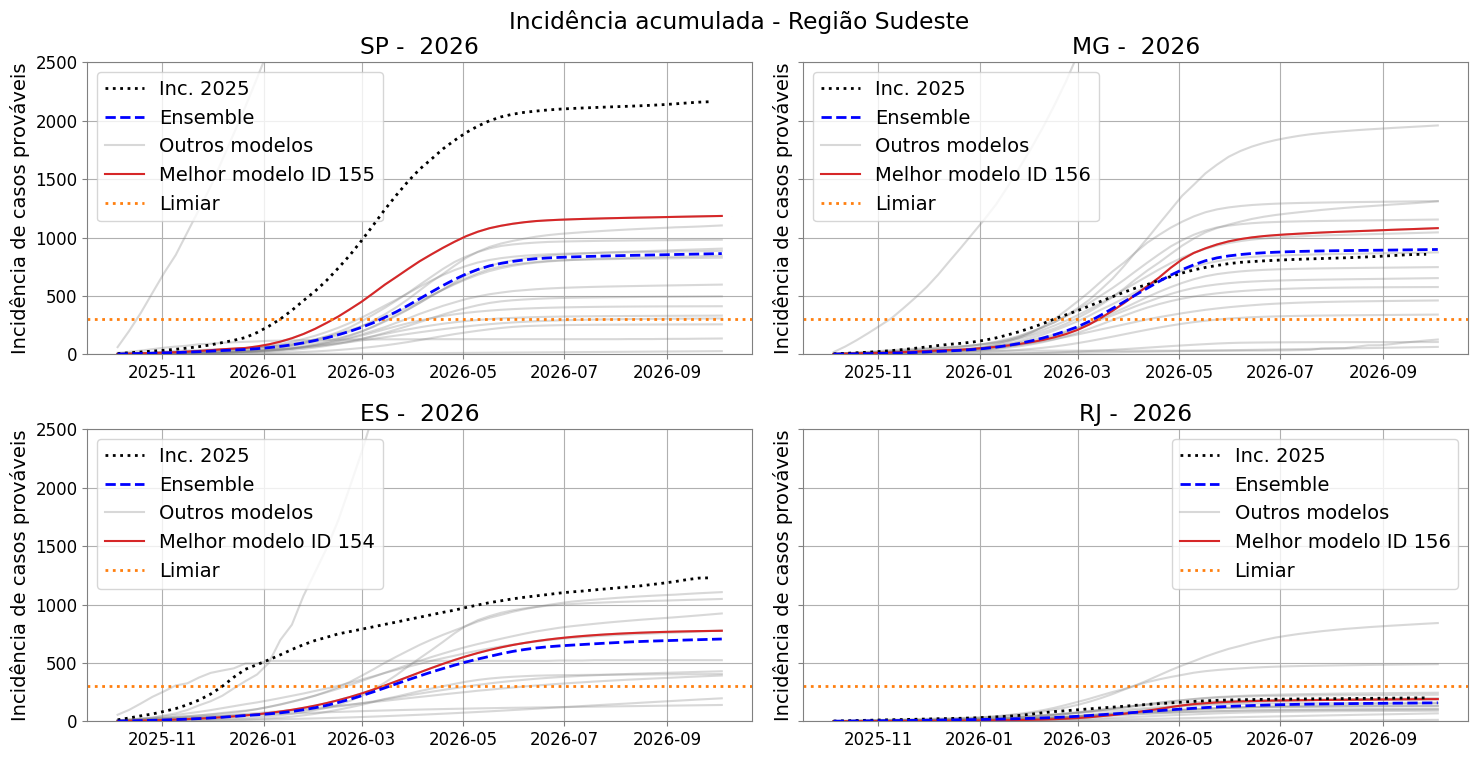

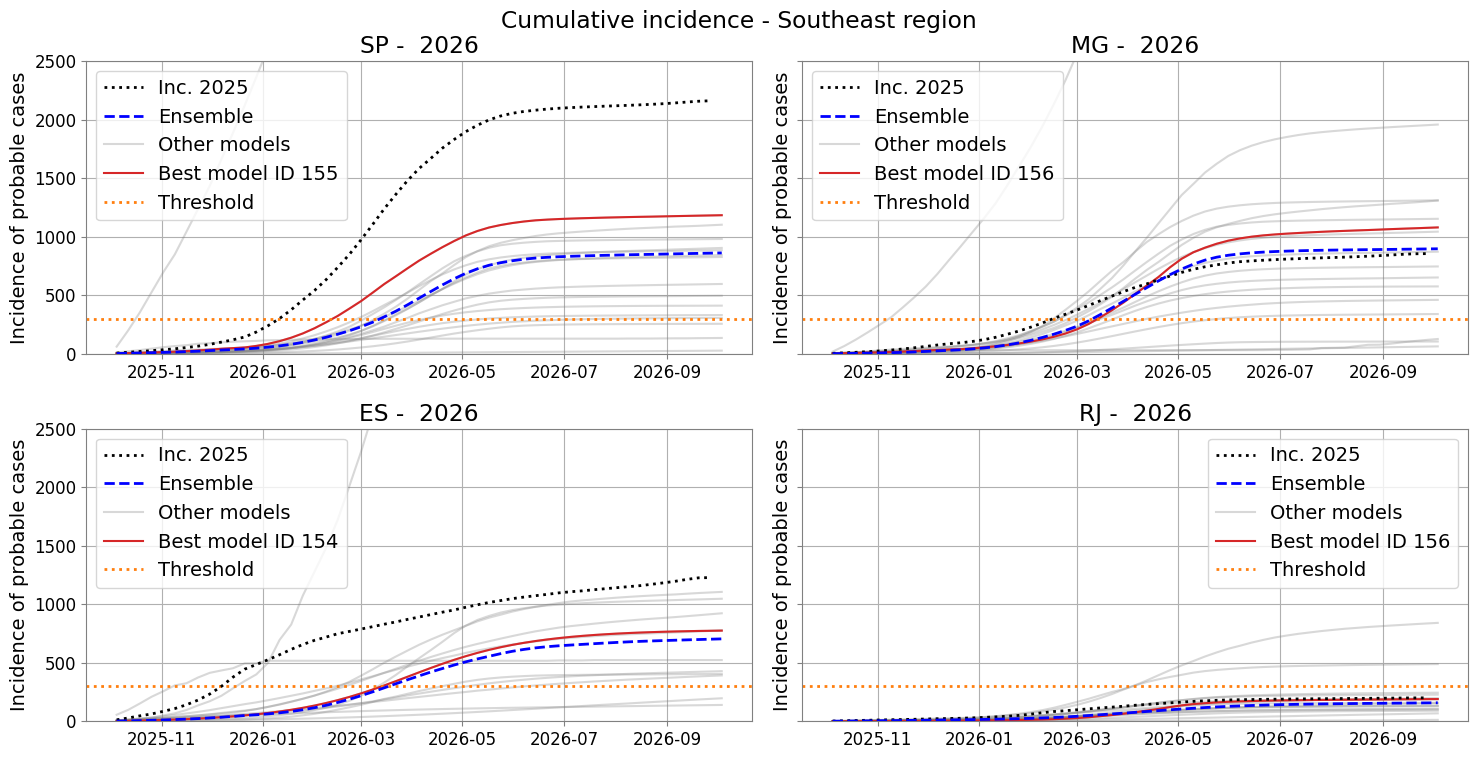

In [16]:
for language in ['pt', 'en']:
 
    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['SP', 'MG', 'ES', 'RJ'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]

        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 2500])

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Sudeste', y = 0.95)
    else: 
        plt.suptitle('Cumulative incidence - Southeast region', y = 0.95)
    
    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_sudeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

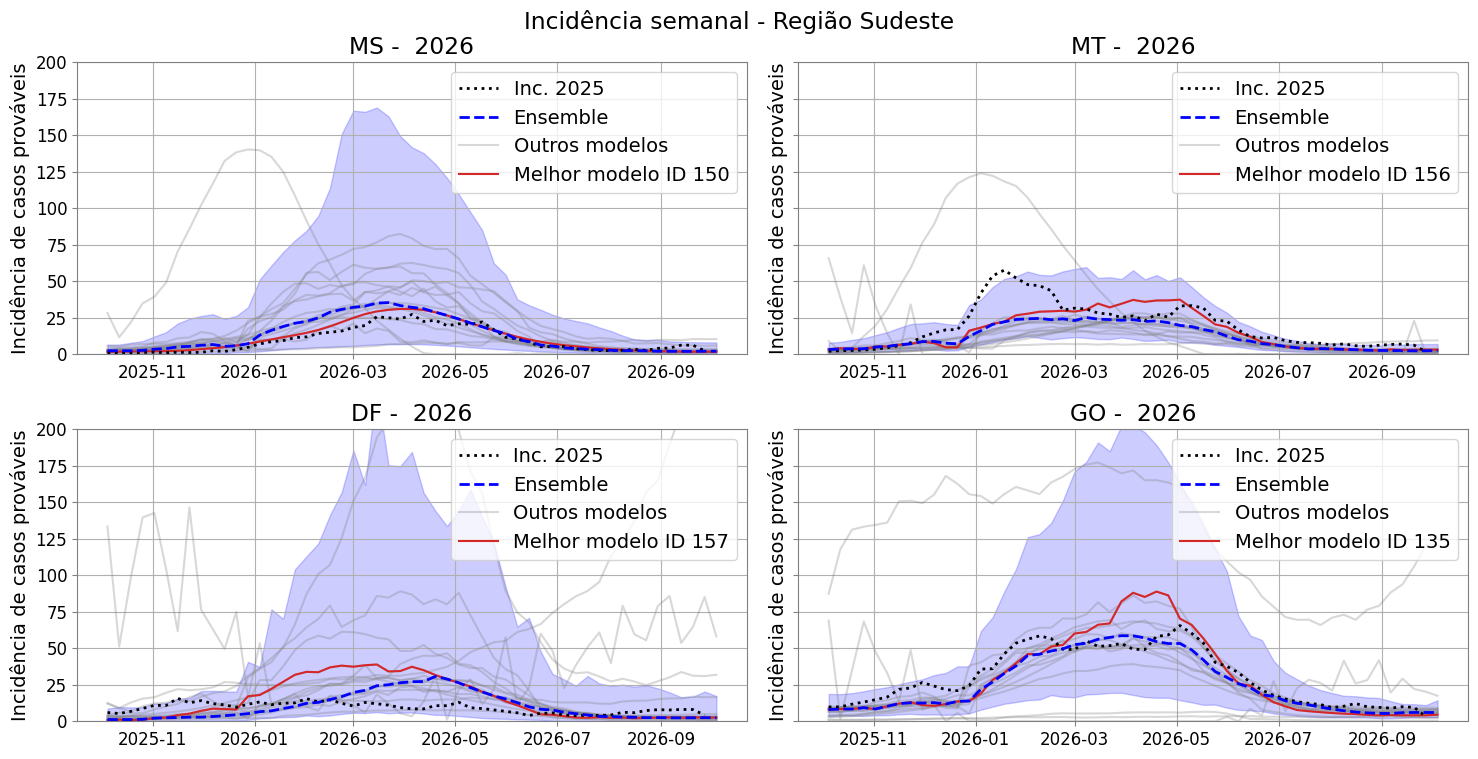

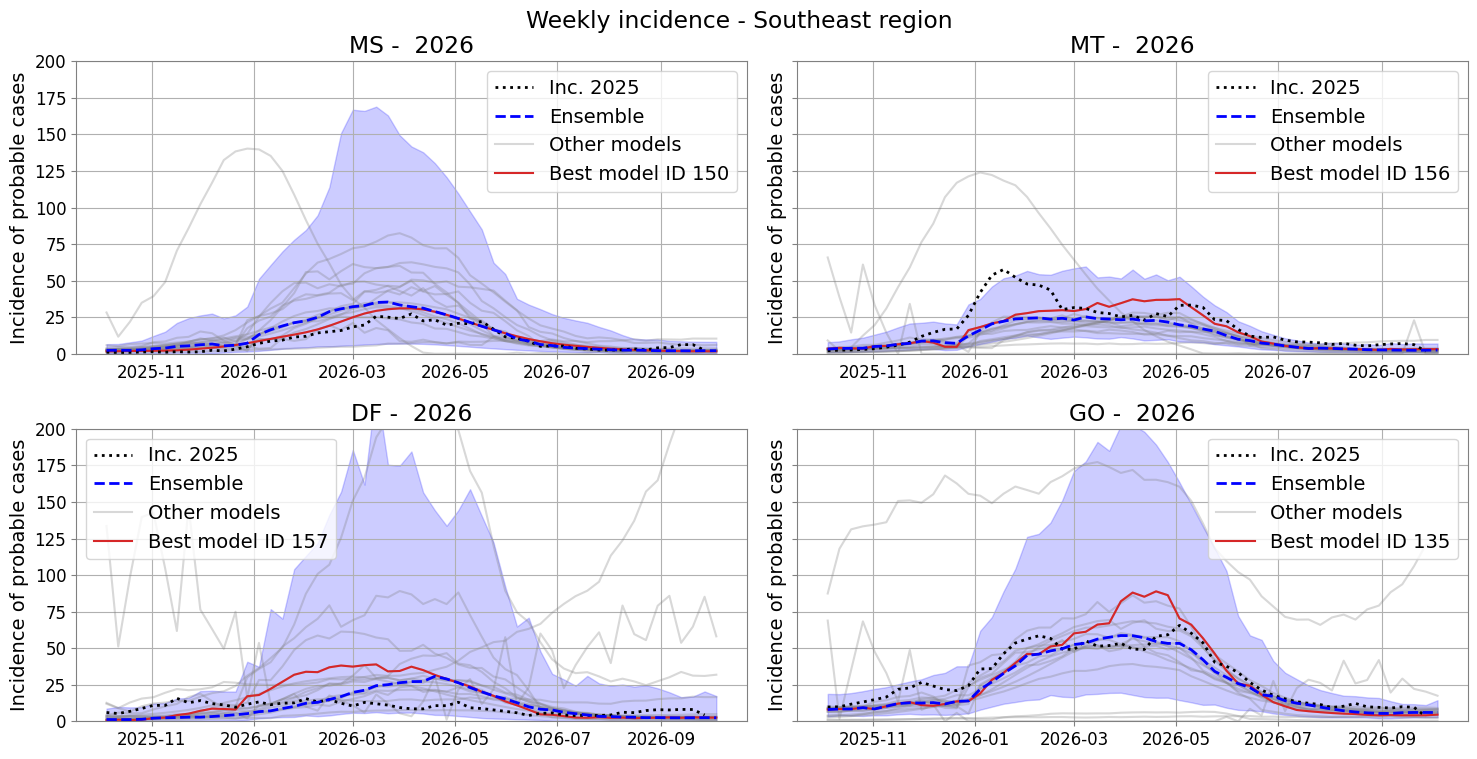

In [17]:
for language in ['pt', 'en']:
 
    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['MS', 'MT', 'DF', 'GO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]

        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 200])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Sudeste', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - Southeast region', y = 0.95)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_centro_oeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

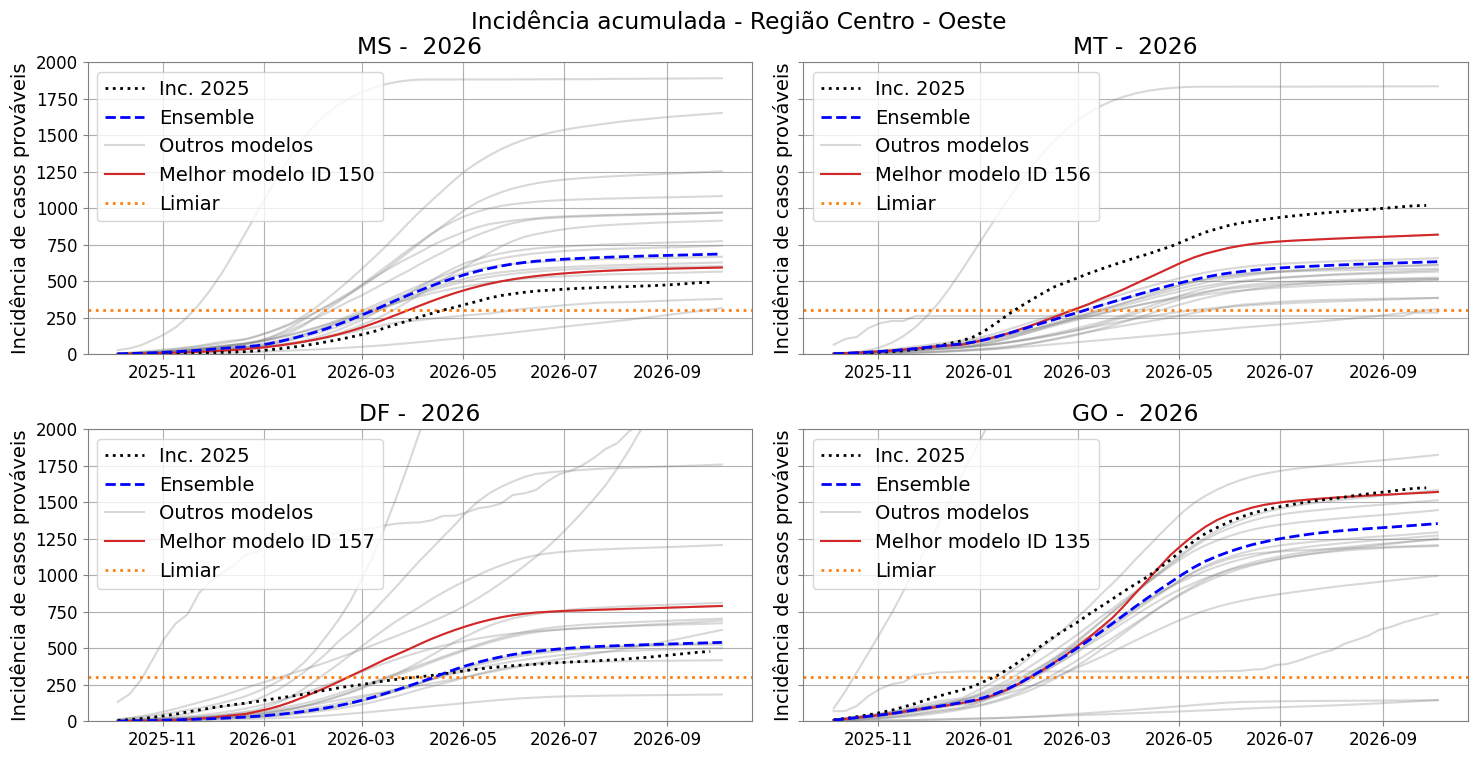

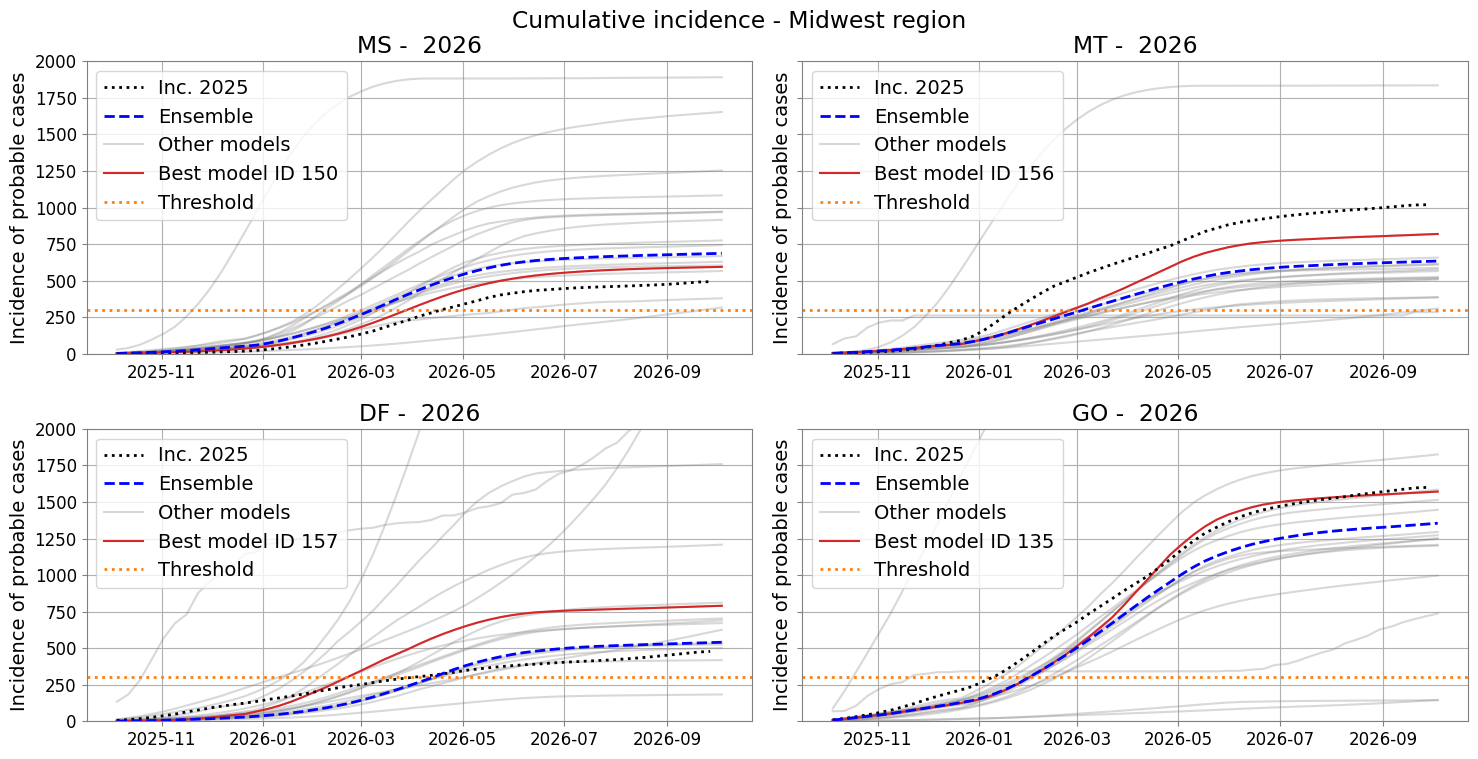

In [18]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(2,2, figsize = (15, 8), sharey = True)

    for state, ax_ in zip(['MS', 'MT', 'DF', 'GO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]

        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 2000])

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Centro - Oeste', y = 0.95)
    else: 
        plt.suptitle('Cumulative incidence - Midwest region', y = 0.95)
    
    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_centro_oeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

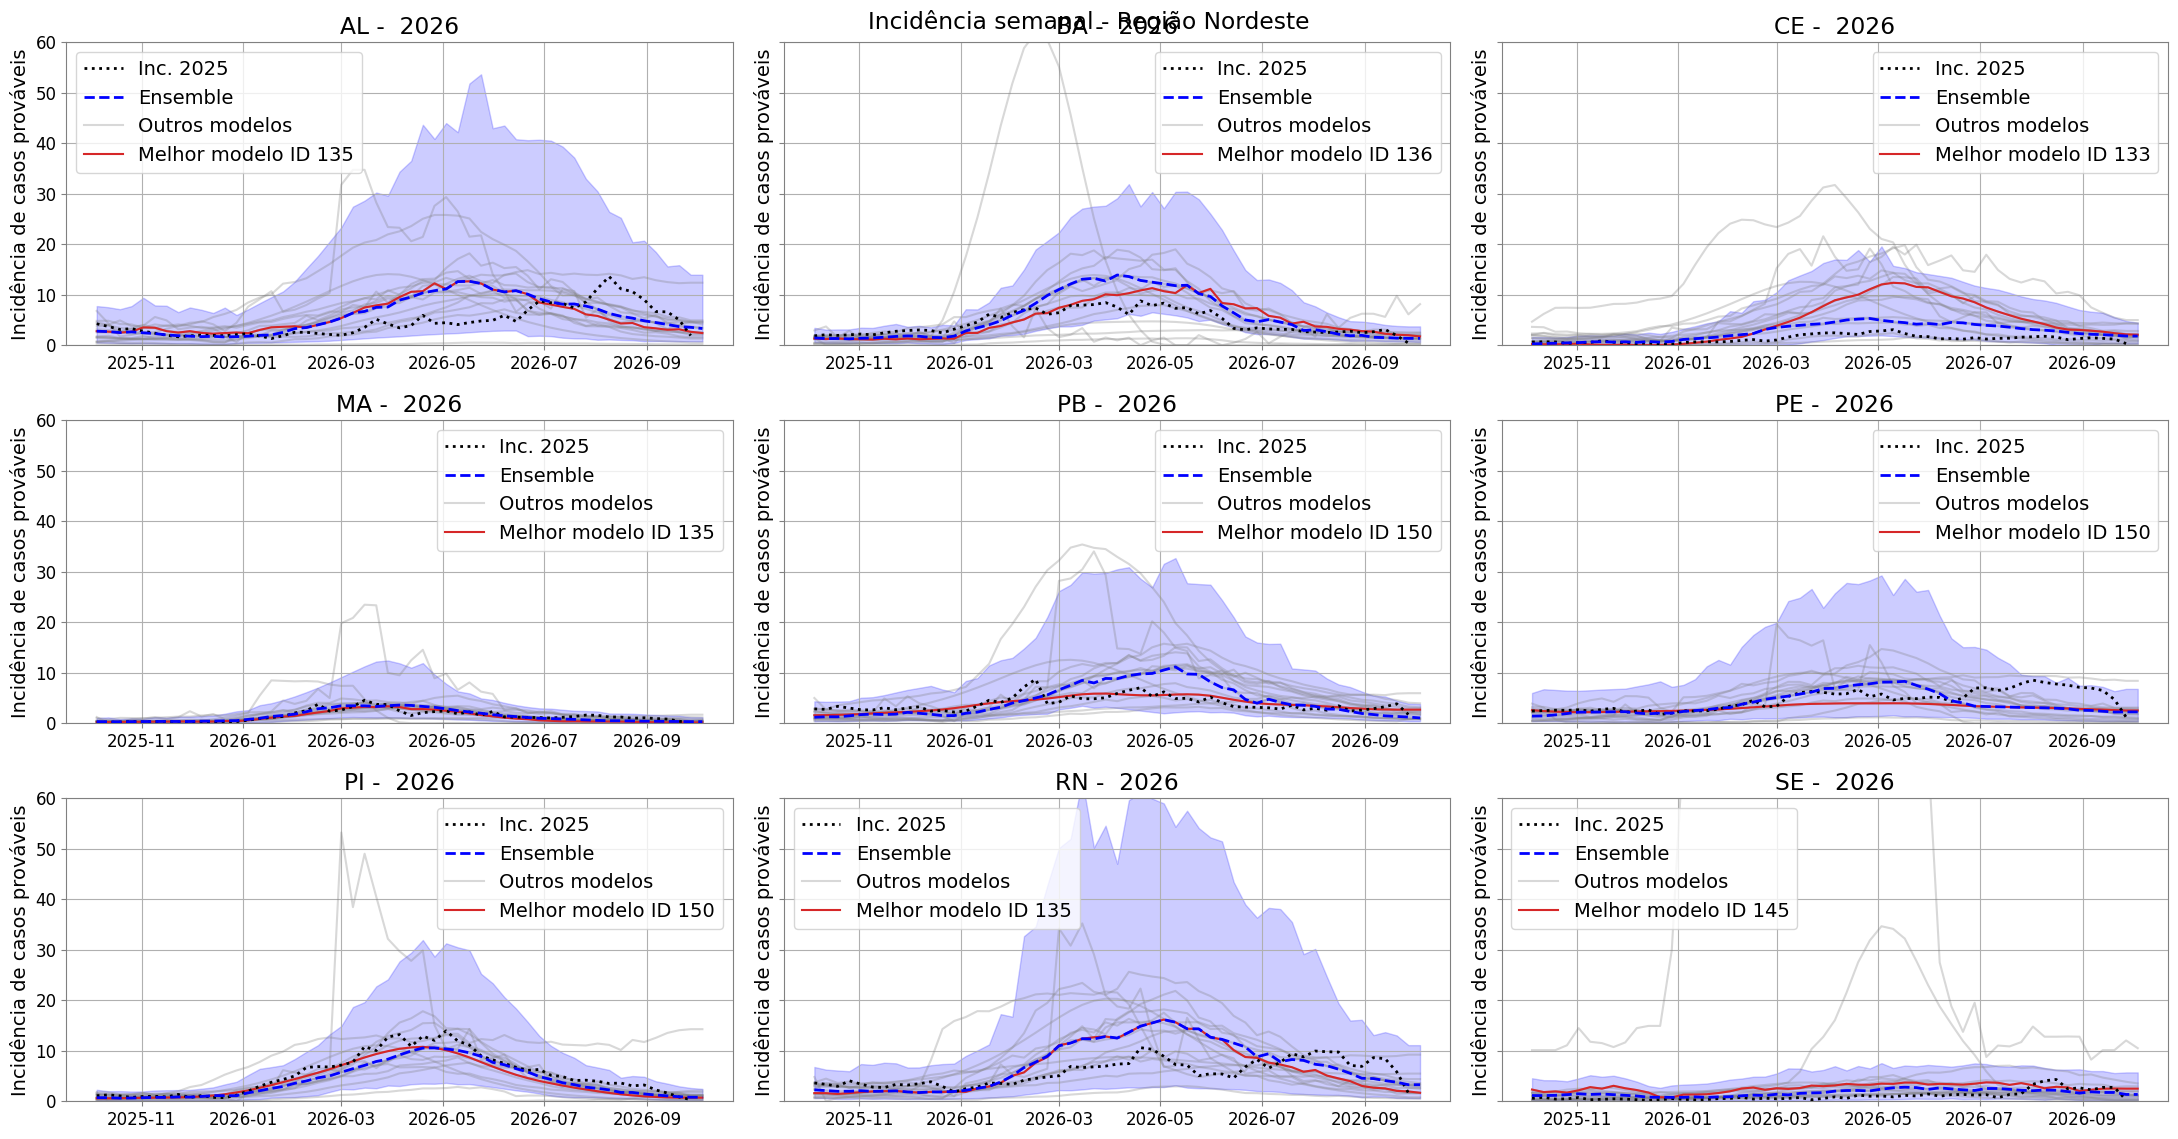

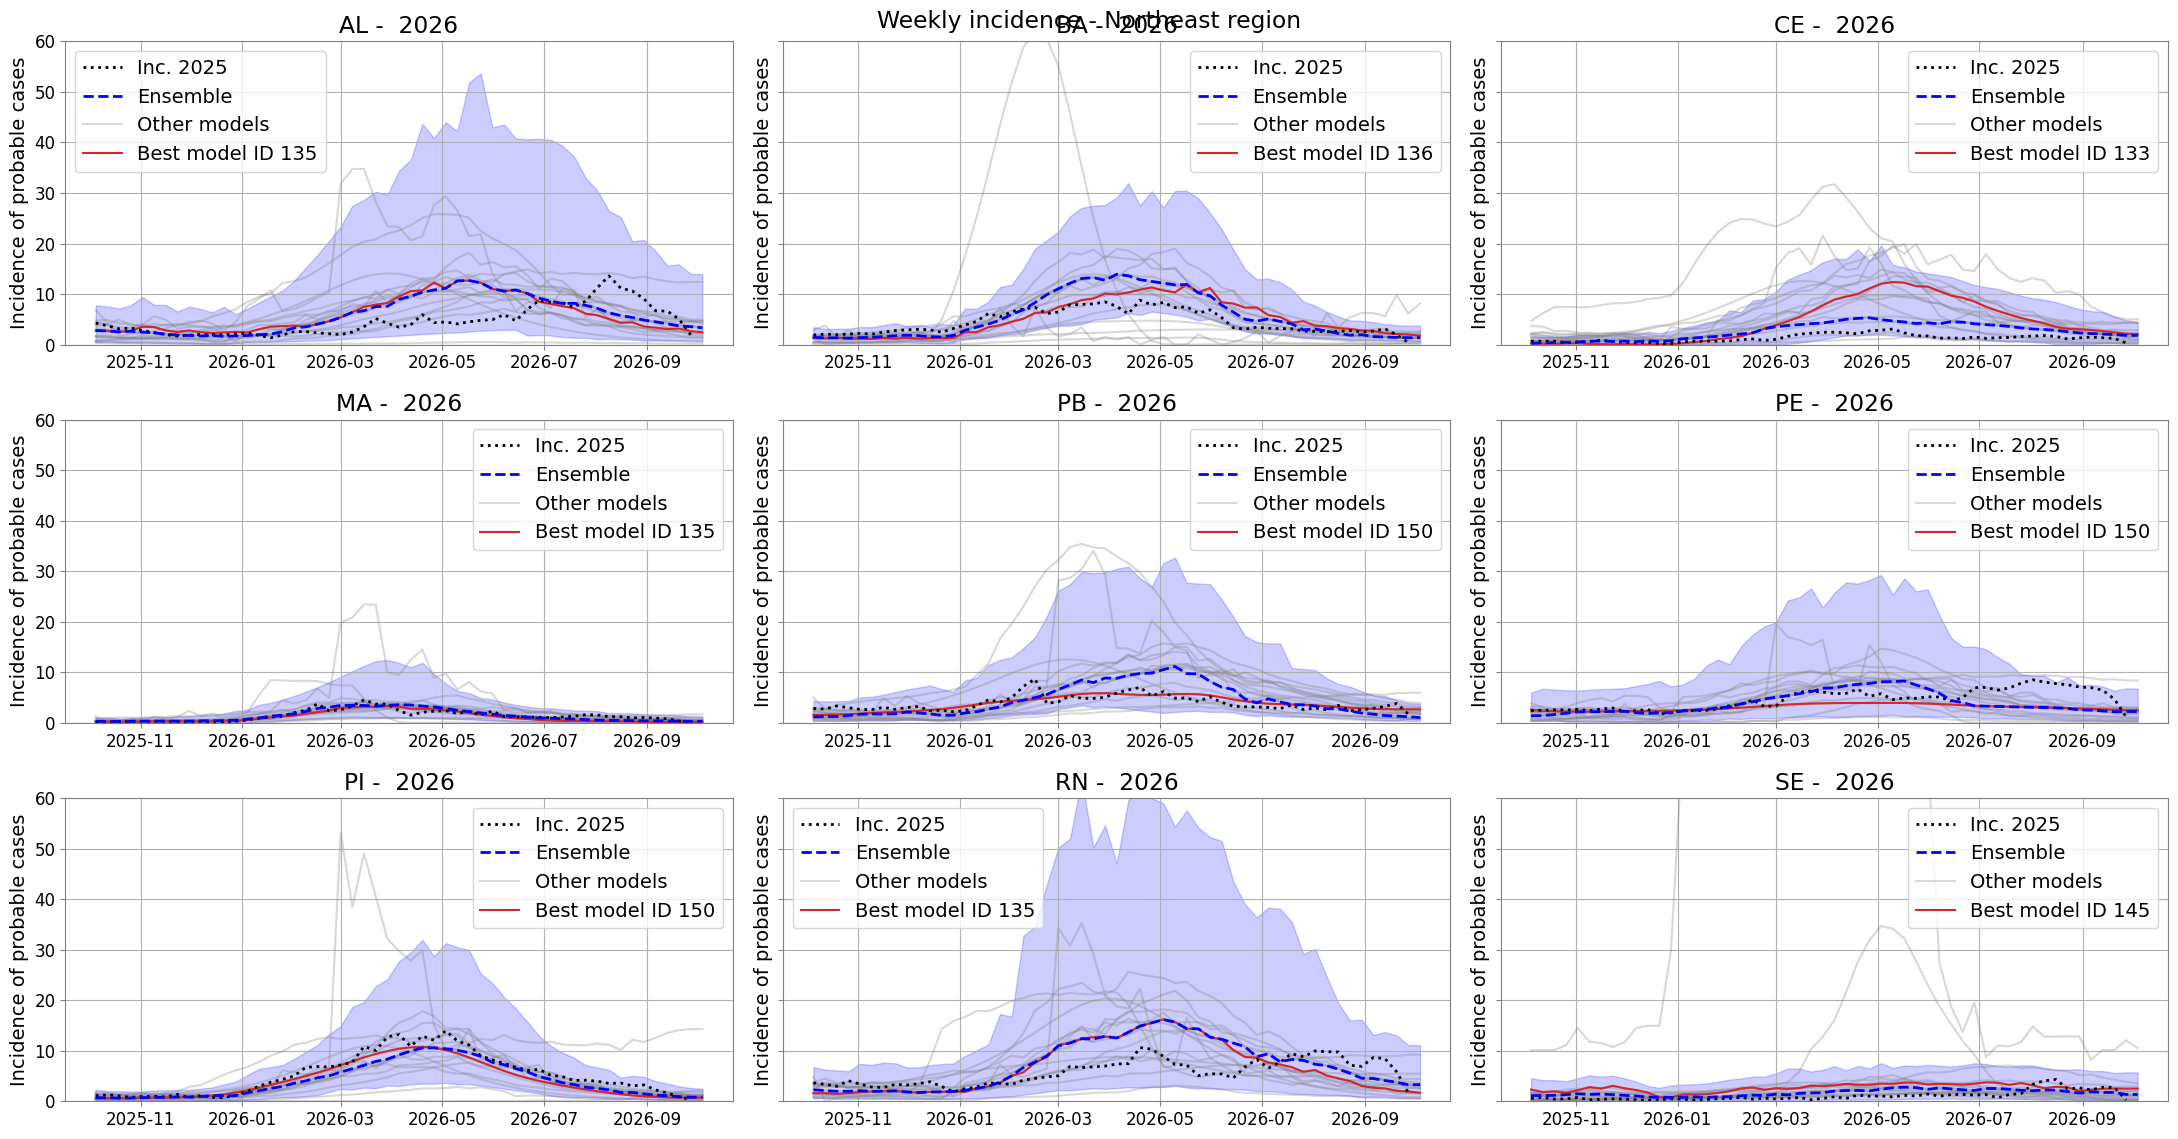

In [19]:
for language in ['pt', 'en']:
    
    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 60])

    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Nordeste', y = 0.95)
    else: 
        plt.suptitle('Weekly incidence - Northeast region', y = 0.95)


    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_nordeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

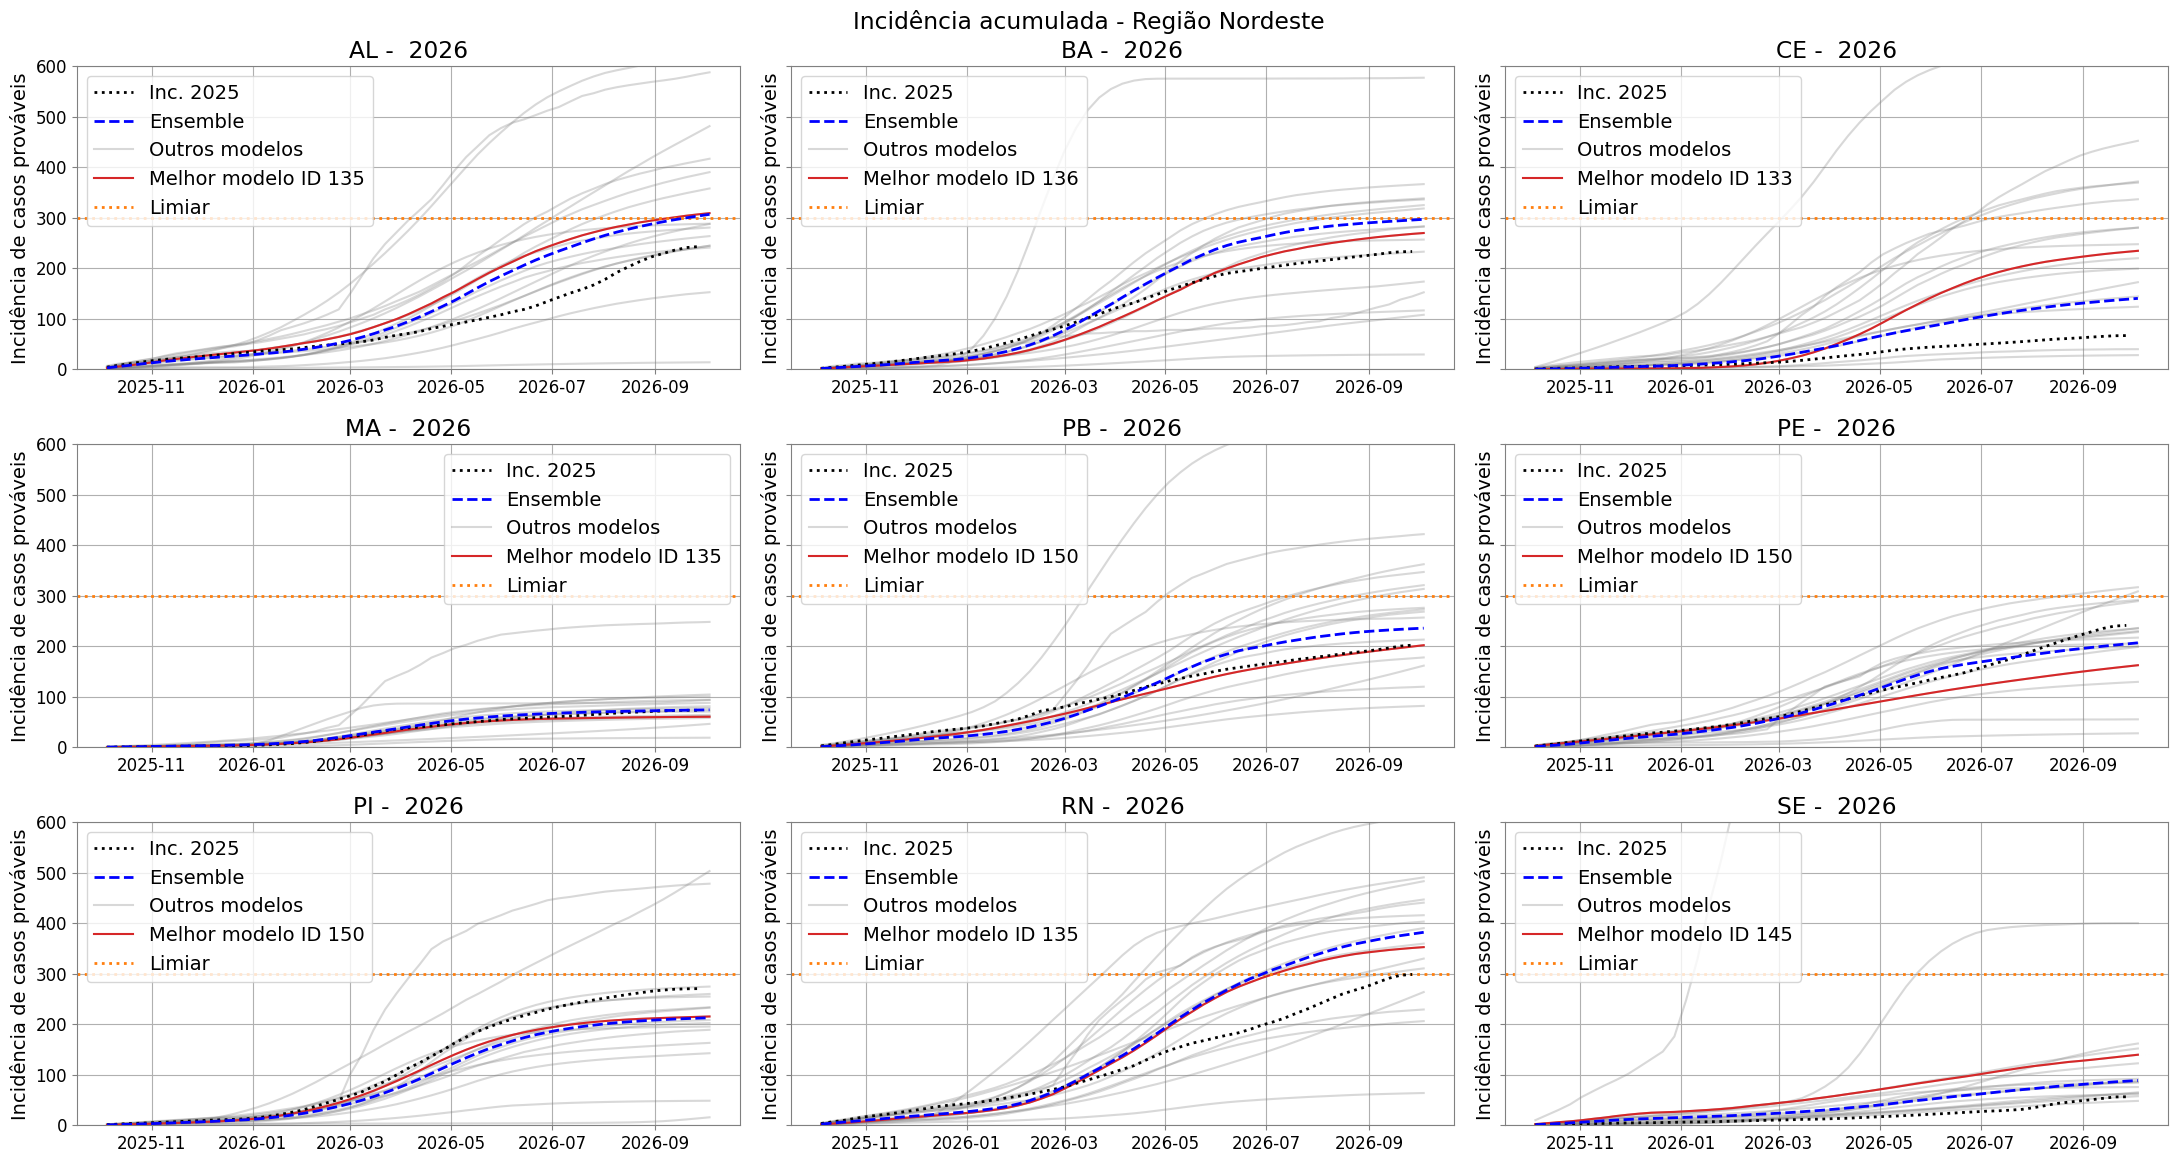

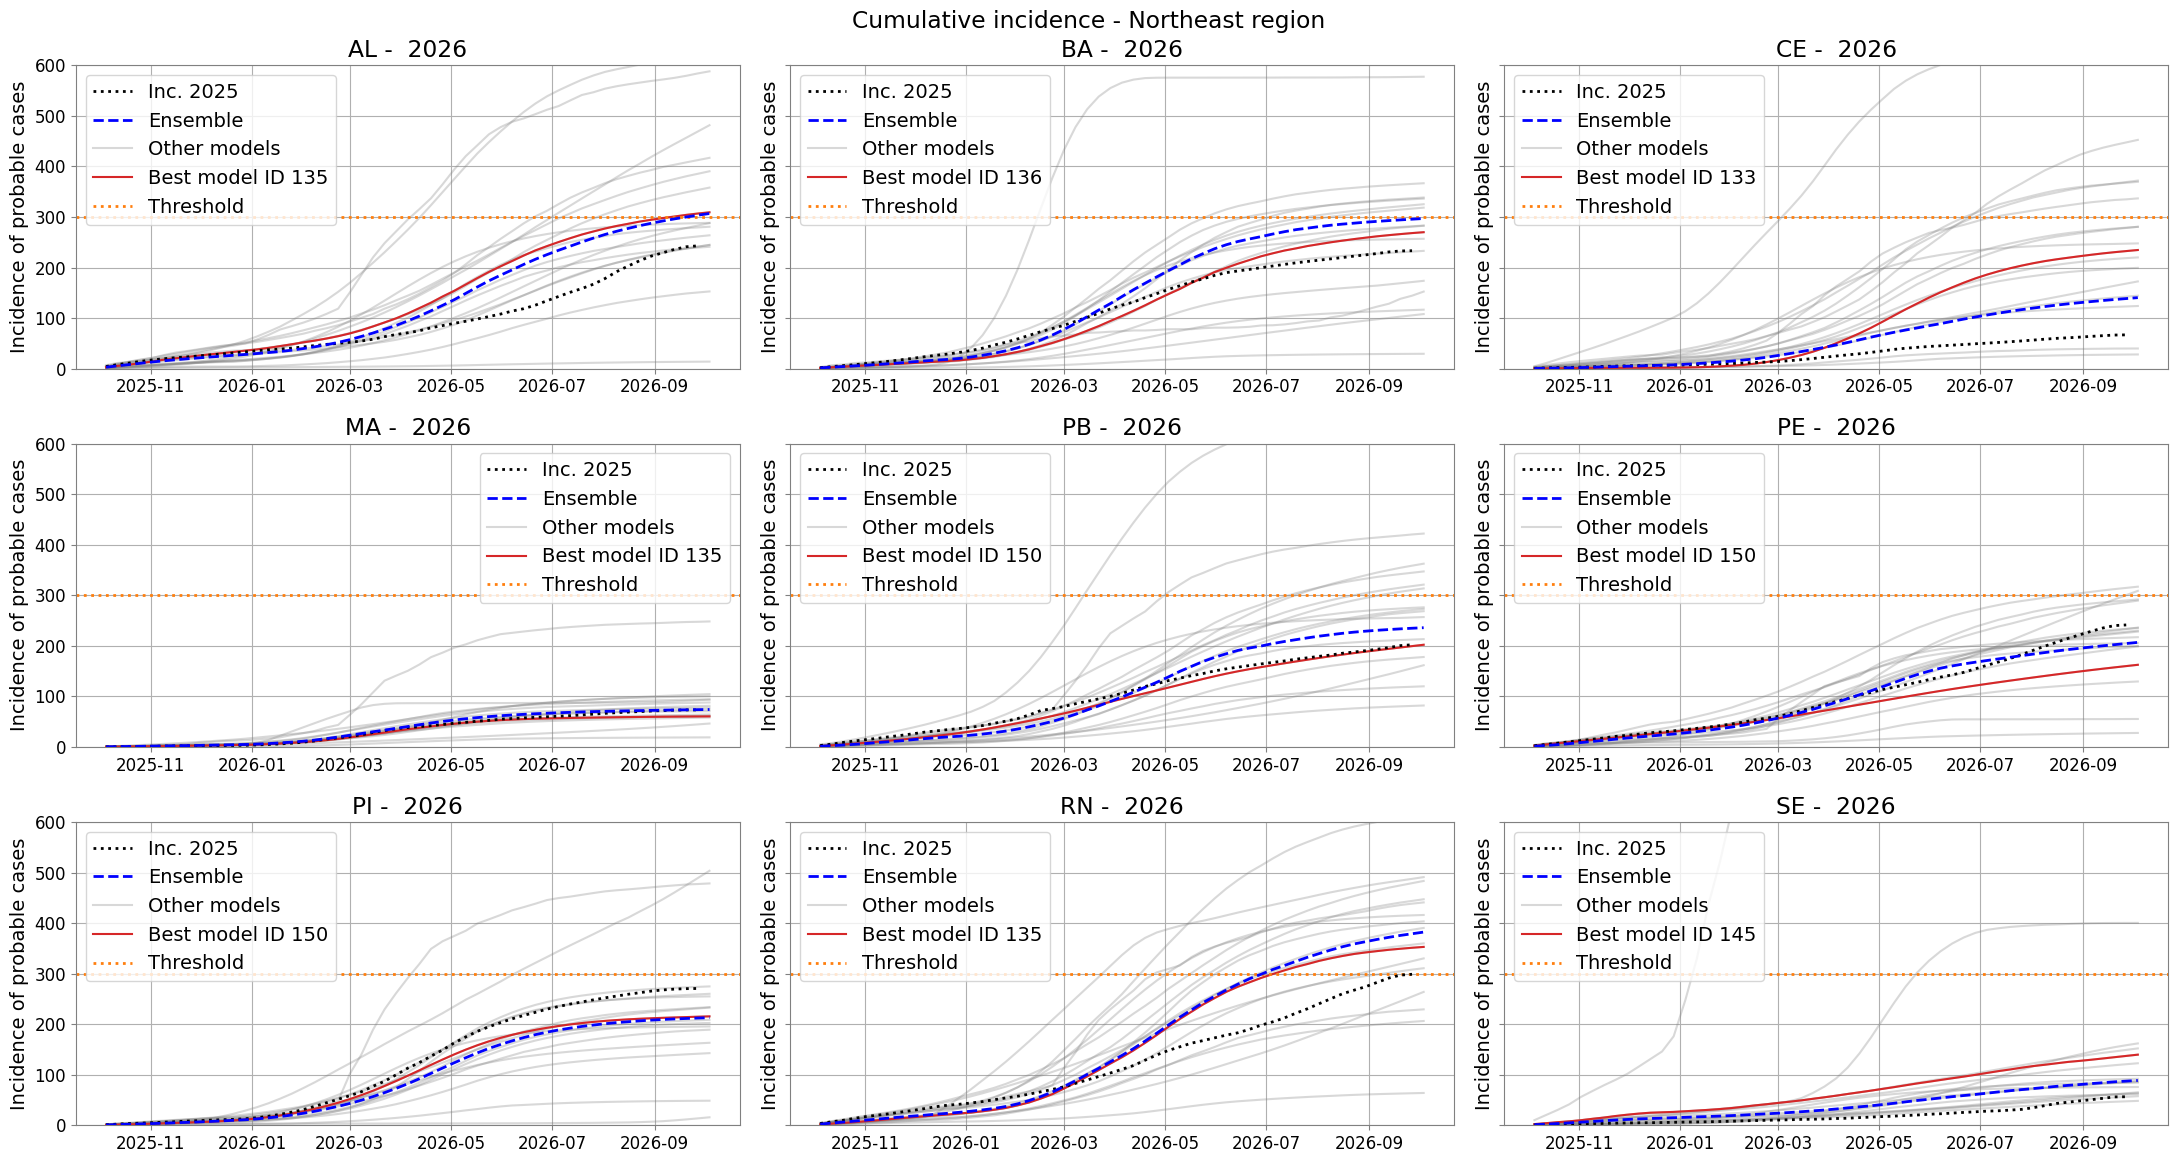

In [20]:
for language in ['pt', 'en']:
    
    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 600])

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Nordeste', y = 0.97)
    else: 
        plt.suptitle('Cumulative incidence - Northeast region', y = 0.97)
    
    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_nordeste_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

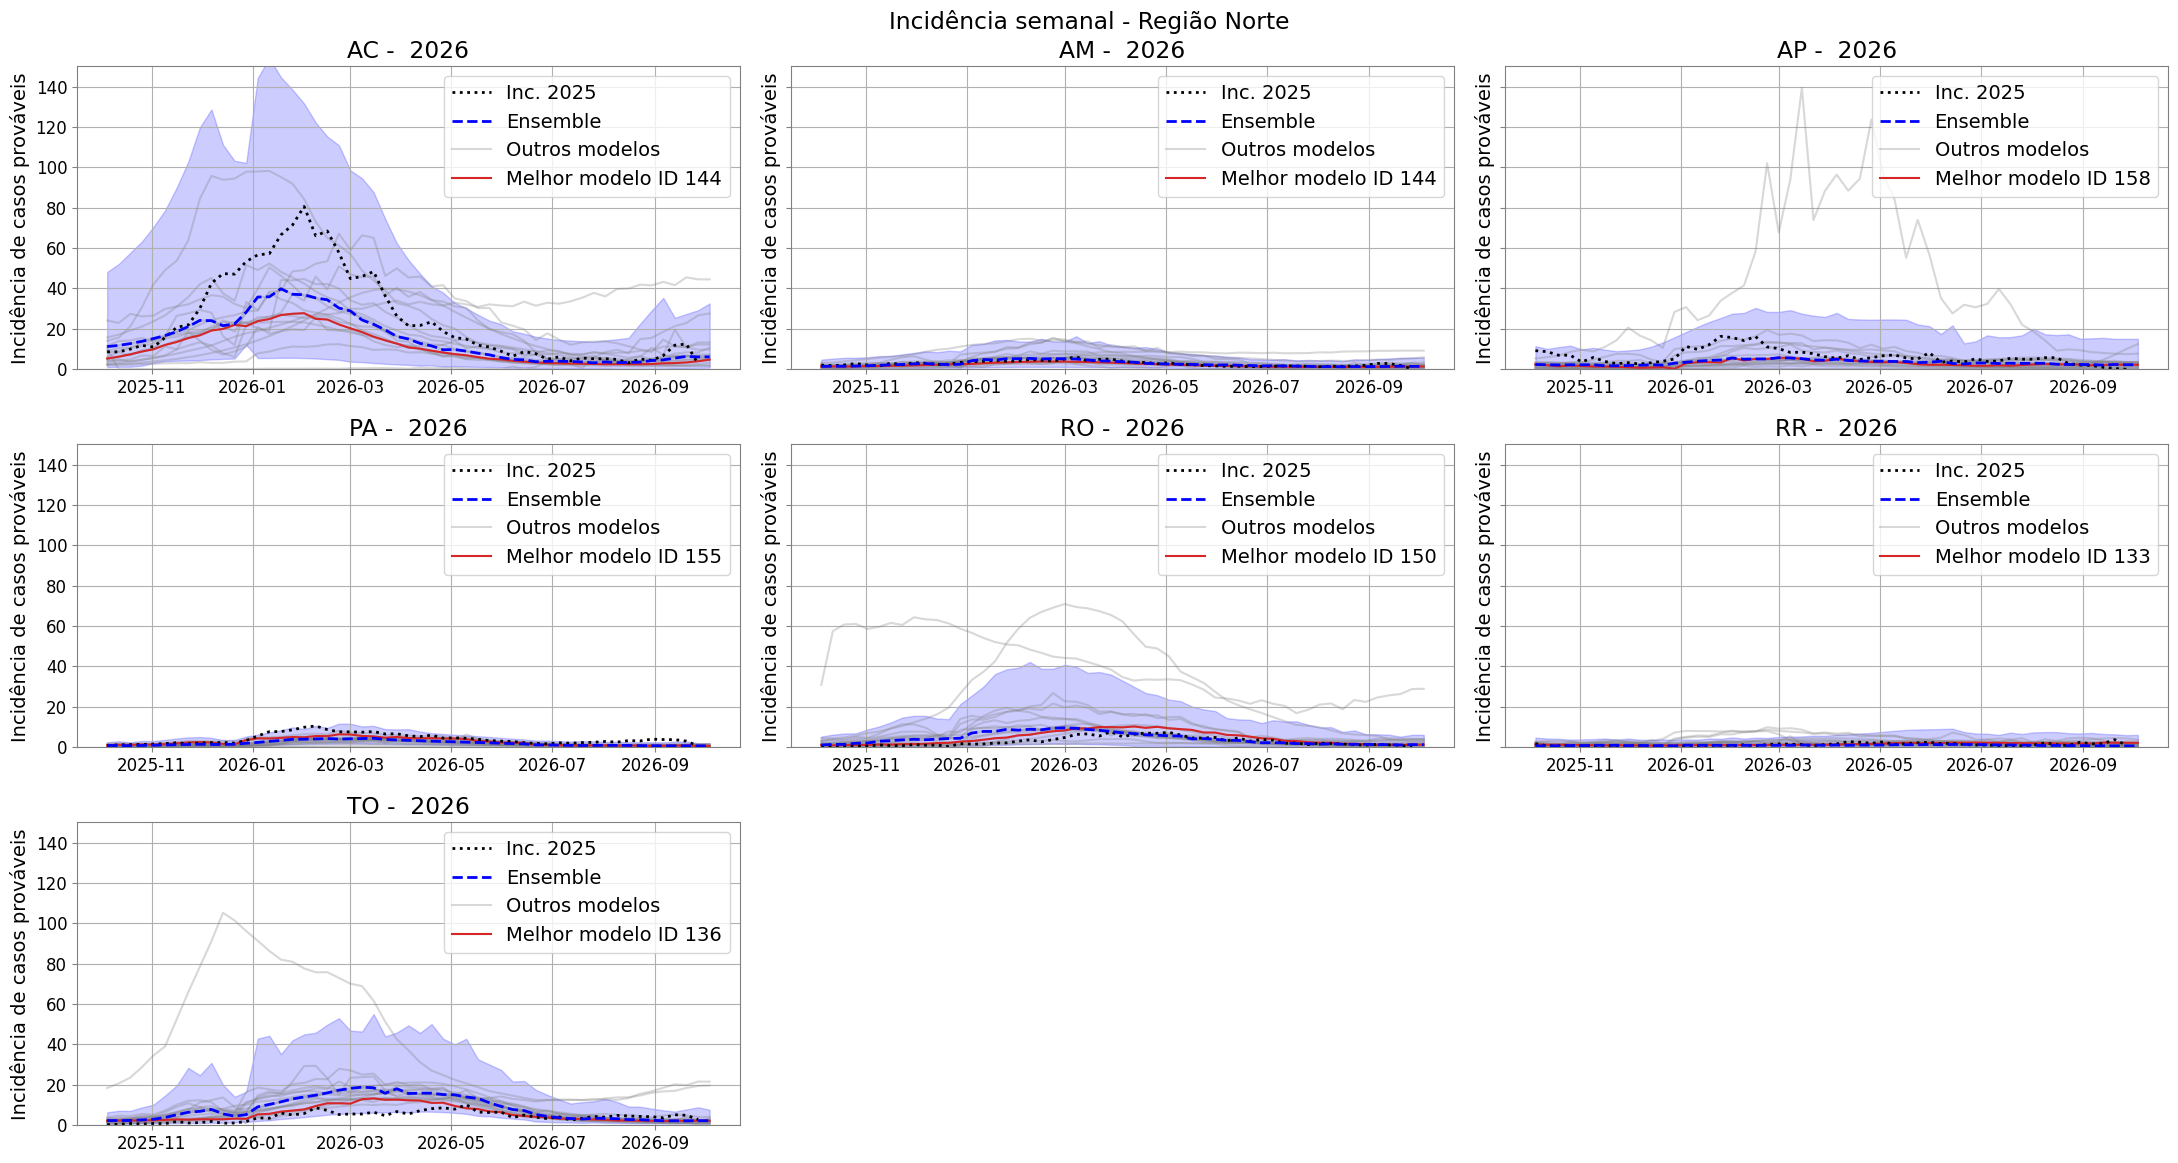

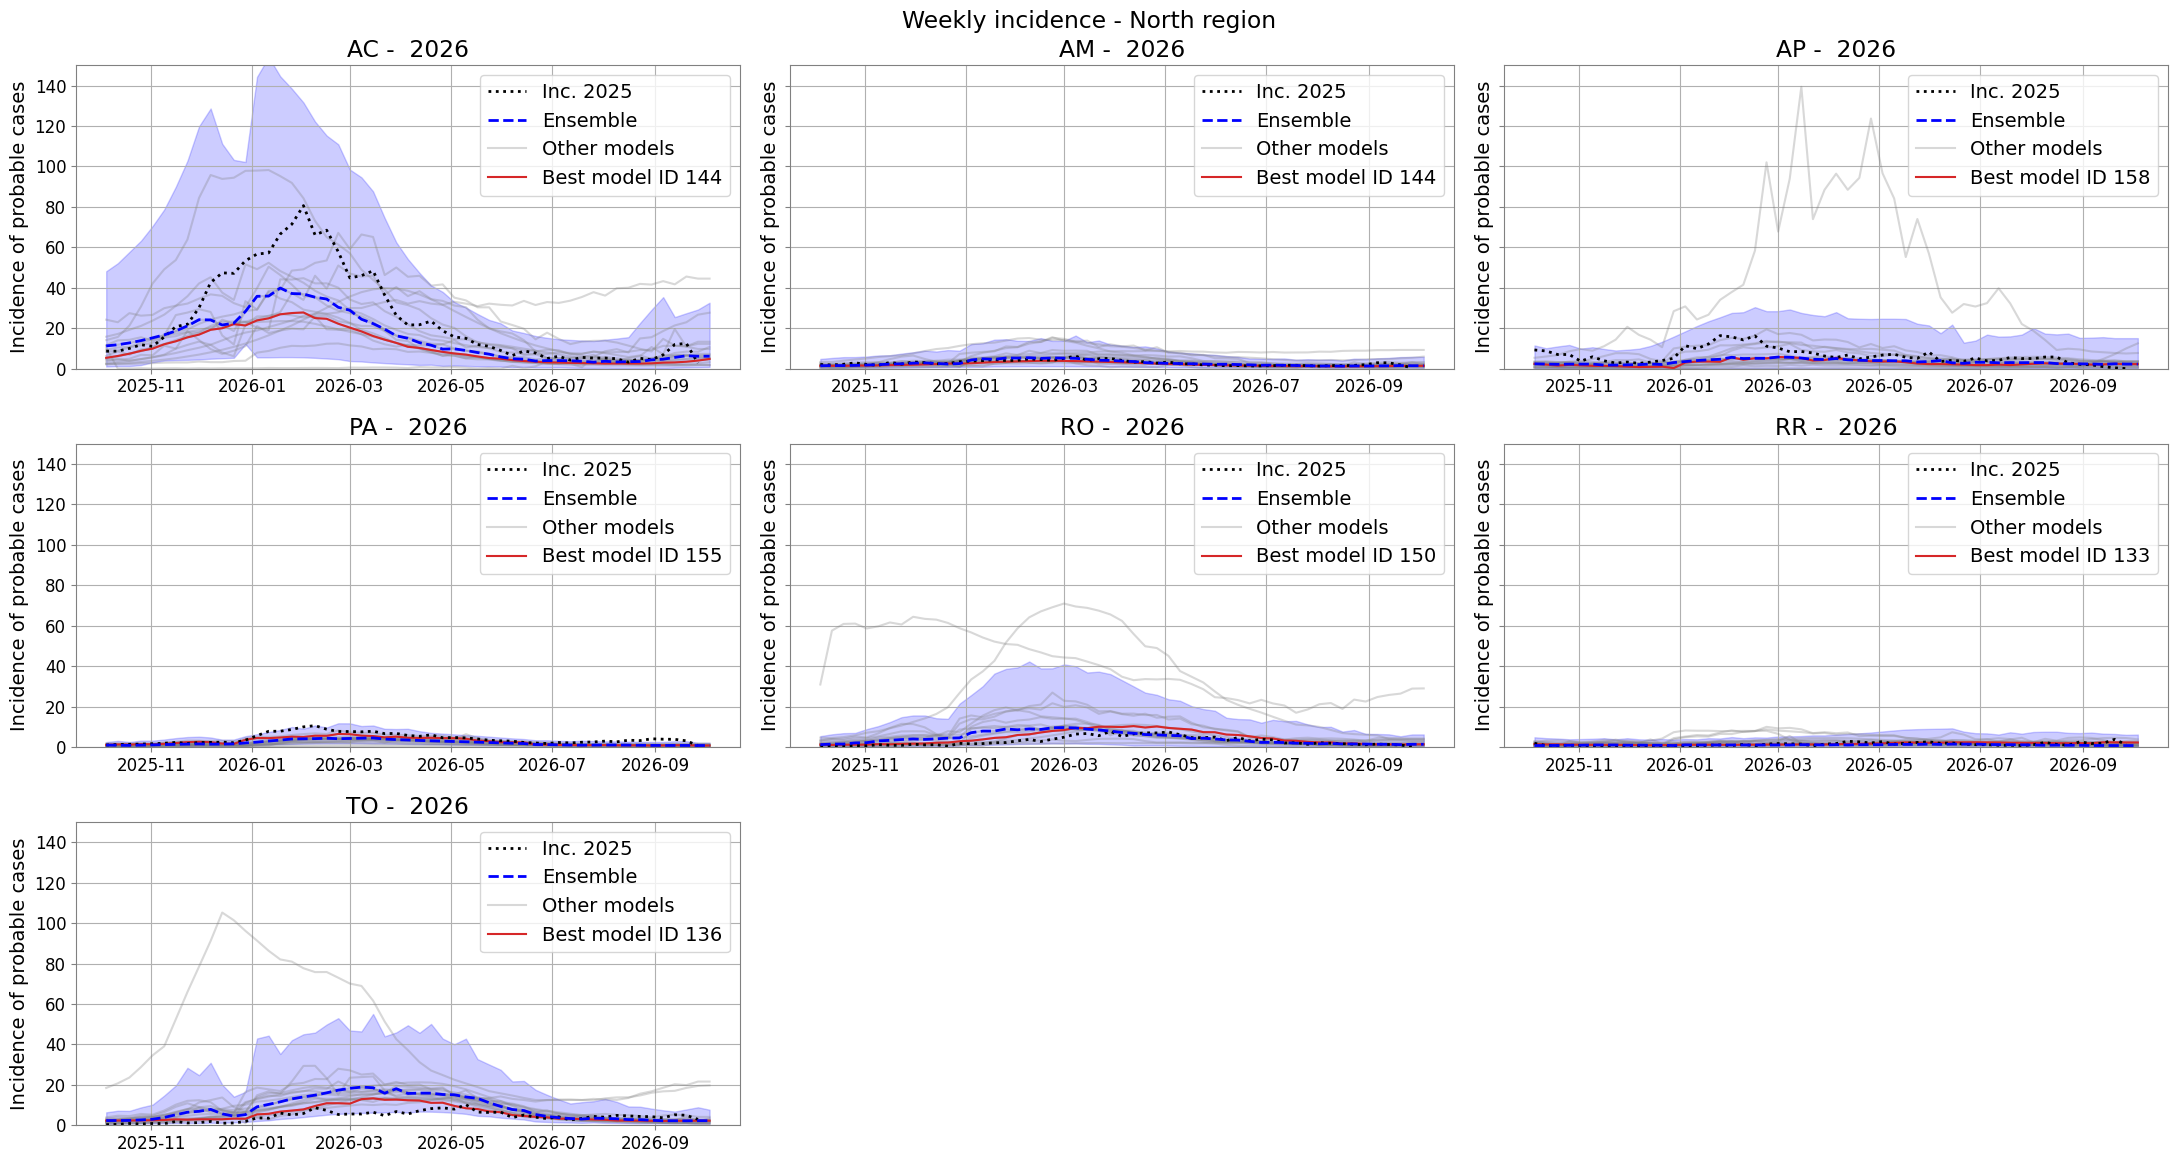

In [21]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=False, language=language)

    ax[0,0].set_ybound([0, 150])
    ax[2,1].axis('off')
    ax[2,2].axis('off')
    
    if language == 'pt': 
        plt.suptitle('Incidência semanal - Região Norte', y = 0.97)
    else: 
        plt.suptitle('Weekly incidence - North region', y = 0.97)

    plt.tight_layout()
    plt.savefig(f'figures/weekly_cases_norte_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

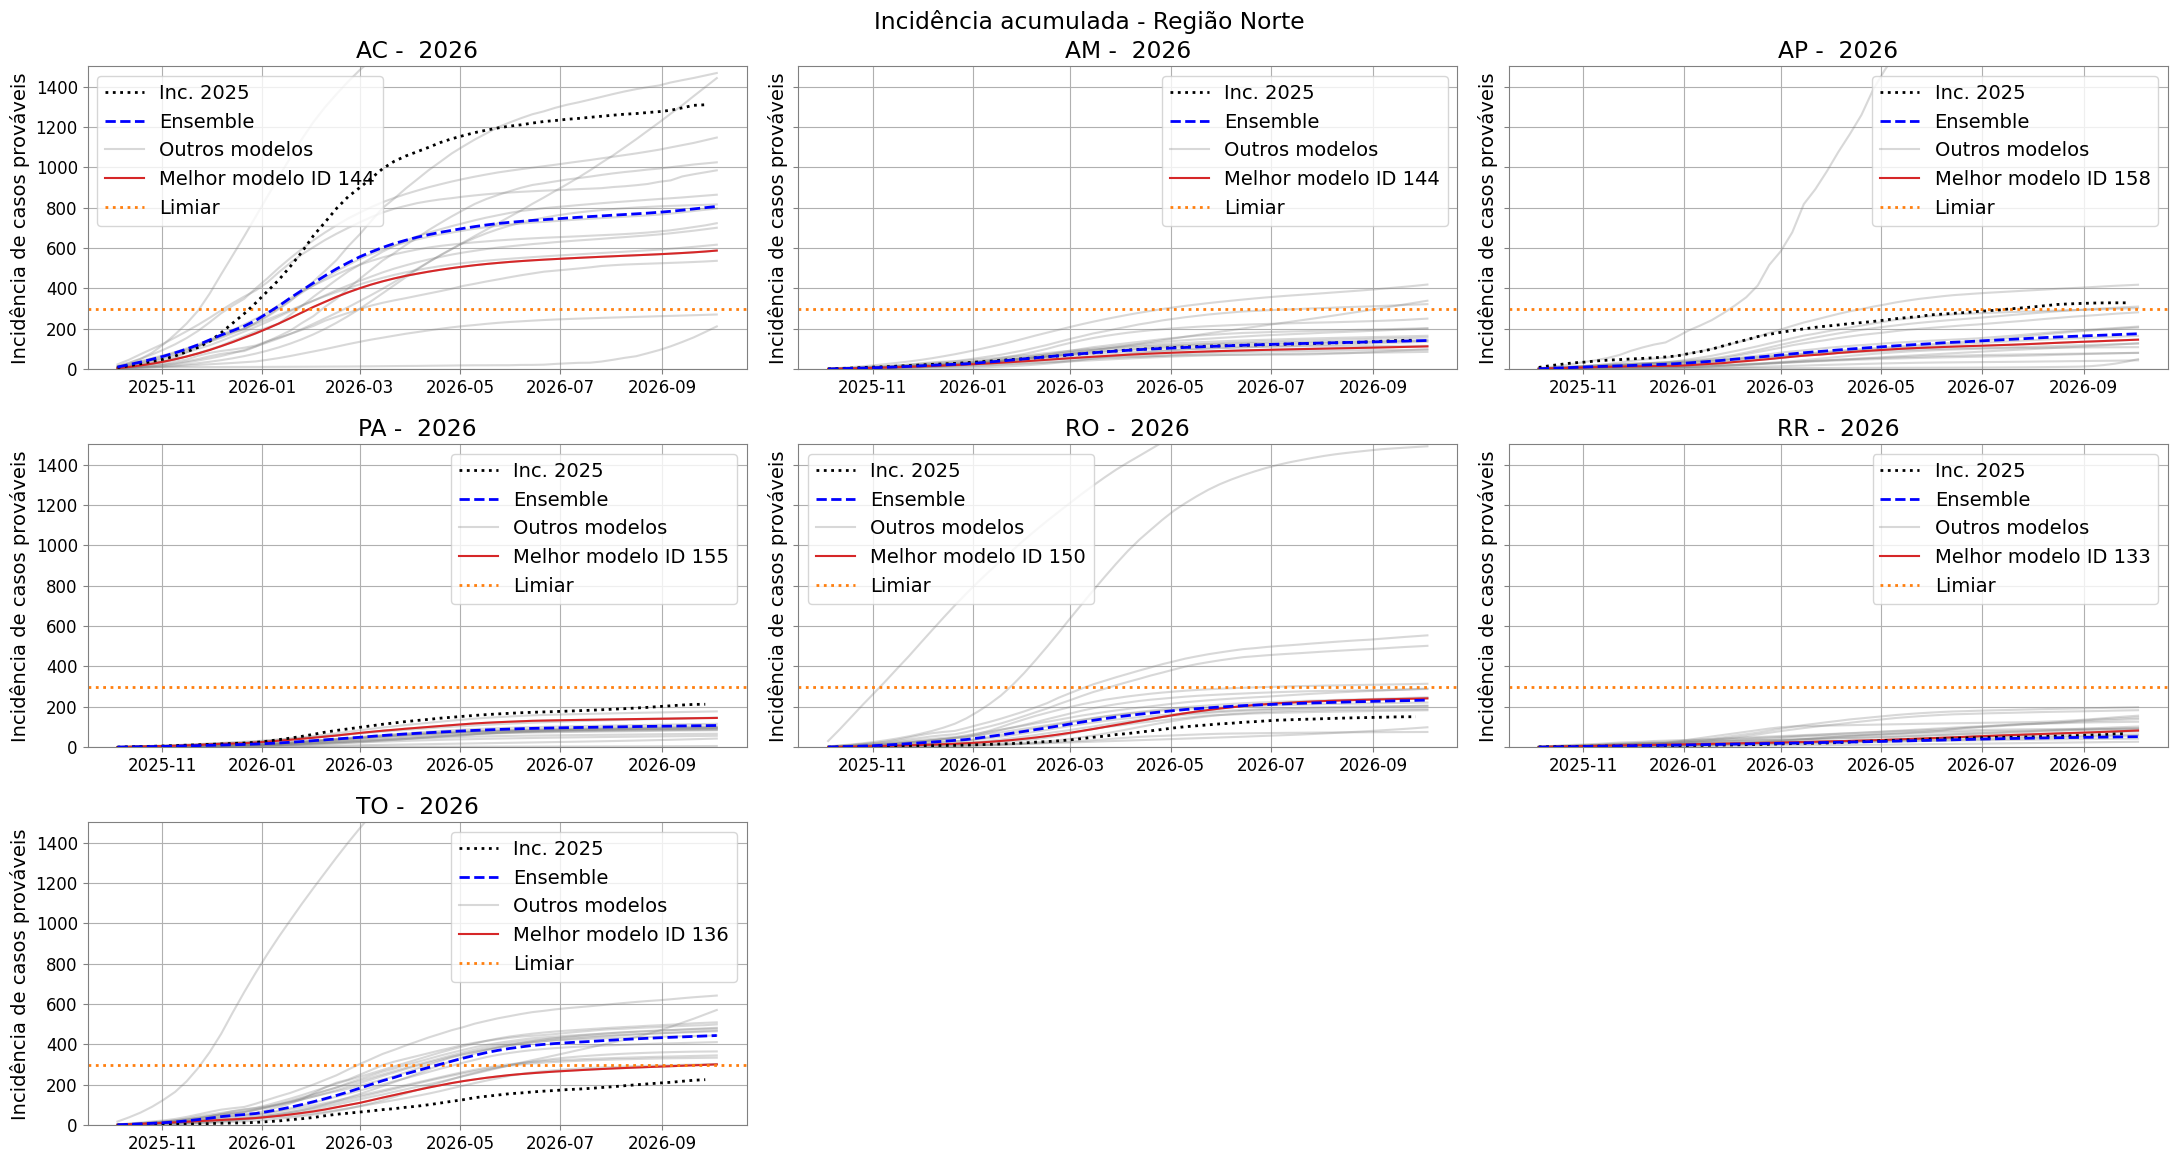

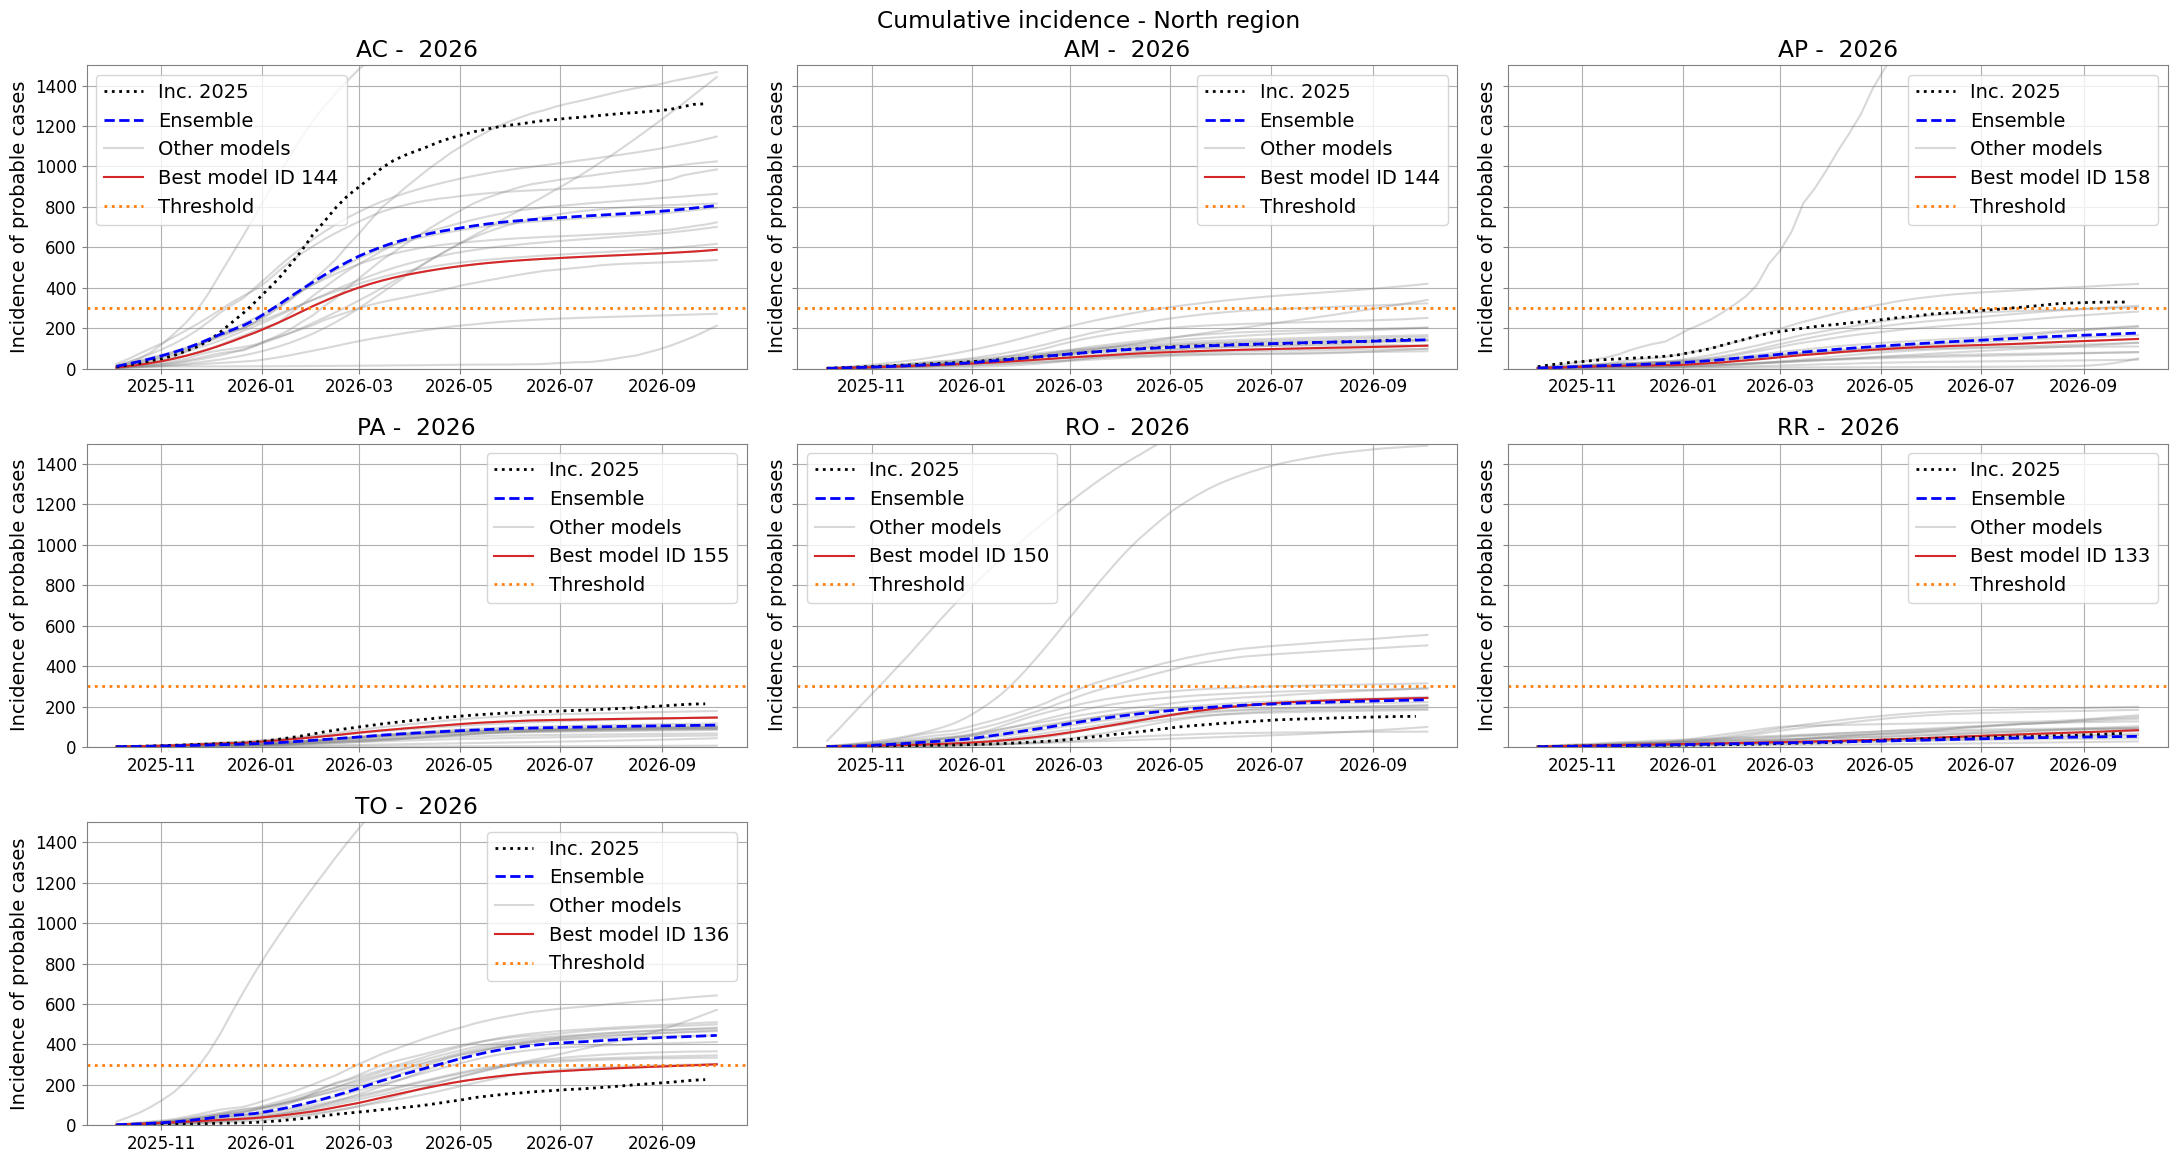

In [22]:
for language in ['pt', 'en']:

    _, ax = plt.subplots(3,3, figsize = (22, 12), sharey = True)

    for state, ax_ in zip(['AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO'], ax.ravel()):
        
        best_model = df_bm.loc[df_bm.state == state]['best_model_norm'].values[0]
        make_comp_plot(ax_, state, best_model, df_median_ens, df_for, cumulative=True, language=language)

    ax[0,0].set_ybound([0, 1500])
    ax[2,1].axis('off')
    ax[2,2].axis('off')

    if language == 'pt': 
        plt.suptitle('Incidência acumulada - Região Norte', y = 0.97)
    else: 
        plt.suptitle('Cumulative incidence - North region', y = 0.97)
    

    plt.tight_layout()
    plt.savefig(f'figures/cumulative_cases_norte_{language}.png', dpi = 400, bbox_inches = 'tight')
    plt.show()

Gráfico dos casos acumulados por para o país:

In [23]:
df_cum_cop = pd.read_csv('predictions/ensemble_median_2026_cum_cases.csv.gz')
df_cum_cop = df_cum_cop.merge(df_pop, on = 'state')
for col in ['lower_90', 'pred', 'upper_90']:

    df_cum_cop[f'inc_{col}'] = 100000*df_cum_cop[col]/df_cum_cop['population']

df_cum_cop.head()

,state,model,lower_90,pred,upper_90,rho,population,inc_lower_90,inc_pred,inc_upper_90
0,PE,median,6114.135203,18690.127178,57541.416383,0.966105,9539029,64.095991,195.933225,603.220898
1,CE,median,3444.601541,10711.140588,35804.477678,0.972429,9233656,37.304850,116.001079,387.760576
2,DF,median,4463.947496,21725.280657,103594.774372,0.960510,2982818,149.655376,728.347511,3473.050463
3,RO,median,1140.542373,3708.065937,13157.876350,0.925388,1746227,65.314668,212.347303,753.503201
4,PA,median,5328.694908,10384.027492,20640.464333,0.943659,8664306,61.501693,119.848347,238.224092


In [24]:
df_cum_best_models = pd.read_csv('predictions/best_models_2026_cum_cases.csv.gz')
df_cum_best_models = df_cum_best_models.merge(df_pop, on = 'state')
for col in ['lower_90', 'pred', 'upper_90']:

    df_cum_best_models[f'inc_{col}'] = 100000*df_cum_best_models[col]/df_cum_best_models['population']

df_cum_best_models.head()

,state,lower_90,pred,upper_90,model_id,population,inc_lower_90,inc_pred,inc_upper_90
0,RR,188.795619,470.924381,1.231674e+03,157,716793,26.338932,65.698797,171.831262
1,AP,220.629907,987.042713,5.113742e+03,158,802837,27.481283,122.944348,636.958903
2,SE,961.884927,1891.884242,4.108112e+03,145,2291077,41.983963,82.576196,179.309213
3,RN,3186.258323,9983.876187,3.167938e+04,156,3446071,92.460612,289.717658,919.289705
4,SP,360069.664901,635895.535254,1.160364e+06,155,45973194,783.216552,1383.187636,2524.001296


In [25]:
order = [
    # Sul
    'PR', 'RS', 'SC',
    # Sudeste
    'ES', 'MG', 'RJ', 'SP',
    # Centro-Oeste
    'DF', 'GO', 'MT', 'MS',
    # Nordeste
    'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE',
    # Norte
    'AC', 'AM', 'AP', 'PA', 'RO', 'RR', 'TO' ]

In [26]:
df_inc = casos_2025.groupby('state')[['casprov_2025']].sum().reset_index(

).merge(df_pop, on = 'state')
df_inc['inc'] = 100000*df_inc['casprov_2025']/df_inc['population']


df_inc['state'] = pd.Categorical(df_inc['state'],
                                     categories = order,
                                     ordered = True)

df_inc = df_inc.sort_values(by = 'state')

df_inc.head()

,state,casprov_2025,population,inc
17,PR,121275.0,11824665,1025.610451
22,RS,90686.0,11229915,807.539505
23,SC,32080.0,8058441,398.091889
7,ES,50388.0,4102129,1228.337773
10,MG,182534.0,21322691,856.055176


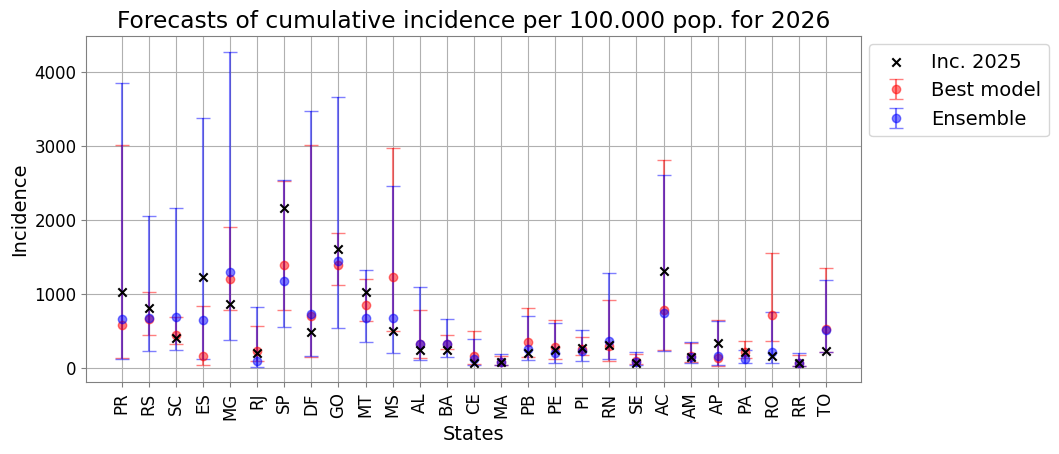

In [27]:
_, ax = plt.subplots(figsize = (10, 4.5))

#ax.axhline(obs, color = 'black', linewidth =2, linestyle = '--', label = 'Data')
ax.scatter(df_inc.state, df_inc.inc, marker = 'x',color = 'black', label = 'Inc. 2025', zorder = 3)

x = df_cum_best_models.state.astype(str)
y = df_cum_best_models.inc_pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_best_models.inc_lower_90, df_cum_best_models.inc_upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_best_models.inc_lower_90, df_cum_best_models.inc_upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='red', ecolor='red', capsize=5, alpha = 0.5, label ='Best model')


# método da cópula
x = df_cum_cop.state.astype(str)
y = df_cum_cop.inc_pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_cop.inc_lower_90, df_cum_cop.inc_upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_cop.inc_lower_90, df_cum_cop.inc_upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='blue', ecolor='blue', capsize=5, alpha = 0.5, label = 'Ensemble')

language = 'en'

if language == 'pt':
    ax.set_ylabel('Incidência')
    ax.set_xlabel('Estados')
        
    ax.set_title(f'Previsão da incidência acumulada por 100.000hab em 2026')

elif language == 'en': 
    ax.set_ylabel('Incidence')
    ax.set_xlabel('States')
        
    ax.set_title(f'Forecasts of cumulative incidence per 100.000 pop. for 2026')
   

#    ax.set_ylim([0, max(2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 1)].casos.values[0],
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 2)].casos.values[0], 
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 3)].casos.values[0])])
#ax.set_yscale('log')
ax.grid()
ax.legend()
for label in ax.get_xticklabels():
        label.set_rotation(90)

handles, labels = plt.gca().get_legend_handles_labels()

# Remove duplicates
unique = dict(zip(labels, handles))

plt.legend(unique.values(), unique.keys(), loc =(1.01,0.71))

plt.savefig(f'figures/cum_inc_2026_{language}.png', dpi = 400, bbox_inches = 'tight')
plt.show()


### Make a map:

In [28]:
import geopandas as gpd 
import matplotlib.colors as colors
from shapely.geometry import Polygon, MultiPolygon


In [29]:
def remove_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)  # mantém só o contorno externo
    elif geom.geom_type == "MultiPolygon":
        # acessa cada polígono dentro do MultiPolygon
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    else:
        return geom
    

df_muni = gpd.read_file('/Users/eduardoaraujo/Documents/sprint_data_2025/shape_muni.gpkg')

df_muni["geometry"] = df_muni.buffer(0)

df_uf = df_muni.dissolve(by="uf")

df_uf["geometry"] = df_uf["geometry"].apply(remove_holes)

df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)

# reset index if you want 'uf' back as a column
df_uf = df_uf.reset_index()

df_uf_m = df_uf.merge(df_cum_cop[['state', 'lower_90', 'pred', 'upper_90',
            'inc_lower_90', 'inc_pred', 'inc_upper_90']].merge(df_inc, on = 'state', suffixes=('_ens', 'data')), left_on = 'uf', right_on = 'state')

df_uf_m['diff_casos'] =   df_uf_m['pred'] -  df_uf_m['casprov_2025']
df_uf_m['diff_inc'] =  df_uf_m['inc_pred'] - df_uf_m['inc']
df_uf_m['ratio_inc'] =  100*df_uf_m['inc_pred']/df_uf_m['inc']

df_uf_m.head()

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_10529/666752115.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_uf["geometry"] = df_uf.buffer(1e-9).buffer(-1e-9)


,uf,geometry,geocode,geocode_name,uf_code,state,lower_90,pred,upper_90,inc_lower_90,inc_pred,inc_upper_90,casprov_2025,population,inc,diff_casos,diff_inc,ratio_inc
0,AC,"POLYGON ((-70.51515 -7.79238, -70.05498 -7.845...",1200013,Acrelândia,12,AC,1971.986164,6478.010180,22902.588578,223.928770,735.610055,2600.702062,11533.0,880631,1309.629118,-5054.989820,-574.019064,56.169342
1,AL,"MULTIPOLYGON (((-38.23759 -9.3298, -38.23759 -...",2700102,Água Branca,27,AL,3132.315437,10278.127702,35161.126954,97.273735,319.186203,1091.925197,7824.0,3220104,242.973519,2454.127702,76.212684,131.366663
2,AM,"POLYGON ((-72.37321 -4.83344, -72.37321 -4.833...",1300029,Alvarães,13,AM,2863.507667,6350.242017,14678.470098,66.885491,148.328241,342.858059,6150.0,4281209,143.651011,200.242017,4.677231,103.255968
3,AP,"MULTIPOLYGON (((-54.87625 2.42669, -54.87625 2...",1600055,Serra do Navio,16,AP,294.976523,1290.230623,5054.153624,36.741770,160.708914,629.536708,2642.0,802837,329.082989,-1351.769377,-168.374075,48.835376
4,BA,"MULTIPOLYGON (((-46.57715 -11.36086, -46.57715...",2900108,Abaíra,29,BA,21973.719627,47054.022848,98162.889987,147.966064,316.851161,661.006727,34630.0,14850513,233.190598,12424.022848,83.660563,135.876474


In [30]:
df_pv = df_uf_m[['uf', 'inc_pred', 'inc', 'ratio_inc']].rename(
    columns = {
        'inc_pred': 'Inc. pred 2026', 
        'inc': 'Inc. 2025',
        'ratio_inc': 'Ratio 2026/2025 (%)'
    }
)

df_pv['uf'] = pd.Categorical(df_pv['uf'],
                                     categories = order,
                                     ordered = True)

df_pv = df_pv.sort_values(by = 'uf')

df_pv.columns

Index(['uf', 'Inc. pred 2026', 'Inc. 2025', 'Ratio 2026/2025 (%)'], dtype='object')

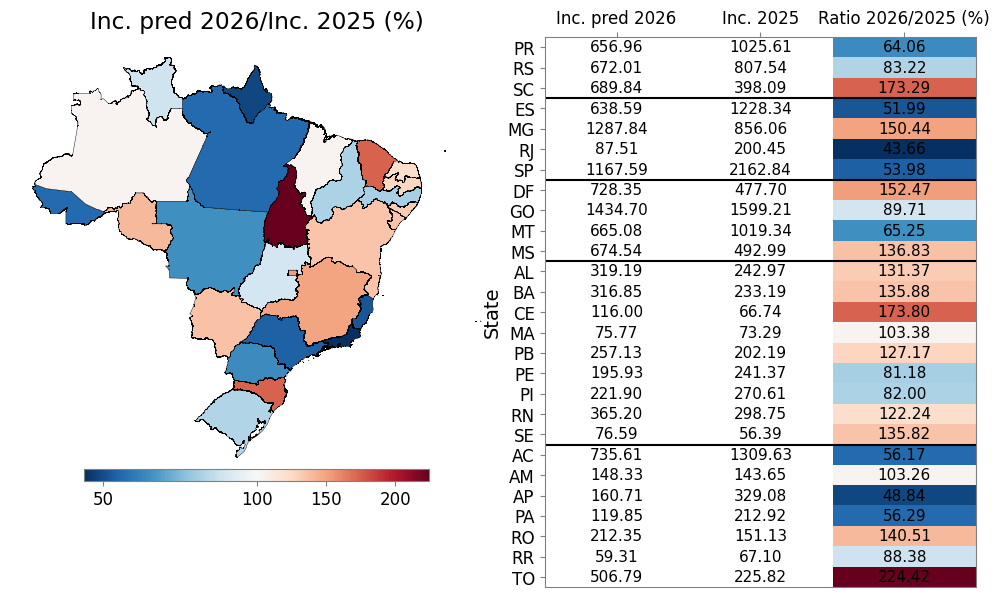

In [31]:
#_, ax = plt.subplots(1,2, figsize = (13, 10),  gridspec_kw={'width_ratios': [2.5, 1],
fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[2,1.5], height_ratios=[2.5,1])

ax_map = fig.add_subplot(gs[0,0])   # map in top-left
ax_table = fig.add_subplot(gs[0,1]) # table in top-right                                     

column = 'ratio_inc'
# Define the center point (e.g., 0, or gdf[column].mean())

# Define normalization so colors diverge from the center
norm = mcolors.TwoSlopeNorm(
    vmin=df_uf_m[column].min(),
    vcenter=100,
    vmax=df_uf_m[column].max()
)

df_uf_m.plot(
    column=column,
    cmap="RdBu_r",      # typical diverging colormap
    norm=norm,          # apply normalization
    linewidth=0.3,
    edgecolor="black",
    ax=ax_map,
    legend=True,
    legend_kwds={
        #"label": "",
        "orientation": "horizontal",  # or "vertical"
        "shrink": 0.6,                # make colorbar smaller
        "pad": 0.05,                  # space between map and colorbar
        "aspect": 30,                 # controls length/thickness
        "anchor": (0.5, 1.5)         # move colorbar (x, y)
    })

#df_uf_m.boundary.plot(ax=ax, color = 'black')
ax_map.axis('off')
#ax.legend()
#ax.legend(handles = handles, title = 'Model', bbox_to_anchor = (1.45, 0.95))

ax_map.set_title('Inc. pred 2026/Inc. 2025 (%)')

cols = ['Inc. pred 2026', 'Inc. 2025', 'Ratio 2026/2025 (%)']
vals = df_pv[cols].values

color_data = np.ones((vals.shape[0], vals.shape[1], 4))

cmap = plt.cm.RdBu_r

for i in range(vals.shape[0]):
    rgba = cmap(norm(df_pv.loc[df_pv.index[i], 'Ratio 2026/2025 (%)']))
    color_data[i, -1, :] = rgba

ax_table.imshow(color_data, aspect='auto')

ax_table.set_xticks(np.arange(len(cols)))
ax_table.set_yticks(np.arange(len(df_pv)))
ax_table.set_xticklabels(cols)
ax_table.set_yticklabels(df_pv['uf'])

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        text_val = vals[i, j]
        ax_table.text(j, i, f"{text_val:.2f}", ha="center", va="center", color="black", fontsize=11)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

ax_table.set_ylabel("State")
ax_table.set_xticklabels(cols, rotation=0, ha='center') 
ax_table.xaxis.set_ticks_position('top')
ax_table.xaxis.set_label_position('top')
#for j in range(1, vals.shape[0]):  # depois de cada coluna, exceto a primeira
ax_table.hlines(3 - 0.5, -0.5, vals.shape[1]-0.5, color='black', linewidth=1.5)
ax_table.hlines(7 - 0.5, -0.5, vals.shape[1]-0.5, color='black', linewidth=1.5)
ax_table.hlines(11 - 0.5, -0.5, vals.shape[1]-0.5, color='black', linewidth=1.5)
ax_table.hlines(20 - 0.5, -0.5, vals.shape[1]-0.5, color='black', linewidth=1.5)

plt.subplots_adjust(wspace=0, hspace=0)
#plt.tight_layout()

plt.savefig('figures/map_table_inc_2026.png', dpi = 400, bbox_inches = 'tight')
plt.show()
